### Import libraries

In [18]:
import re
import numpy as np
import pandas as pd
from pathlib import Path
import matplotlib.pyplot as plt
import math
from mpl_toolkits.mplot3d.art3d import Poly3DCollection
import matplotlib.patches as mpatches
from matplotlib.patches import FancyArrowPatch
import matplotlib.gridspec as gridspec
import warnings; warnings.filterwarnings('ignore', category=UserWarning, message='.*tight_layout.*')


In [19]:
printing = False
plotting = True

### Default functions

In [20]:

def inches(meters):
    return 1/0.0254 * meters

def meters(inches):
    return 0.0254 * inches

def weight(density, length, diameter, thickness):
    return 9.81 * density * length * np.pi * diameter * thickness

def buoyancy(density, length, diameter, thickness):
    return 9.81 * density *np.pi/4 * (diameter * thickness)**2 * length

def length(x1, x2, y1=0, y2=0, z1=0, z2=0):
    return np.sqrt((x1-x2)**2 + (y1-y2)**2 + (z1-z2)**2)

def norm_type(t: str) -> str:
    s = str(t).strip().upper()
    if s in ("LEG", "L"):
        return "Leg"
    if s == "H":
        return "H"
    if s == "K":
        return "K"
    return s

def parse_nodes_connected(value):
    if pd.isna(value):
        return None
    s = str(value).strip()
    m = re.fullmatch(r"\s*(\d+)\s*-\s*(\d+)\s*", s)
    if not m:
        return None
    return int(m.group(1)), int(m.group(2))

# Calculate the equivalant beam
def equivalent_beam_properties(h_i, I_top_i, I_bottom_i, M_legs_total, M_bracing_total, E):
    h_i = np.asarray(h_i, dtype=float)
    I_top_i = np.asarray(I_top_i, dtype=float)
    I_bottom_i = np.asarray(I_bottom_i, dtype=float)

    if not (len(h_i) == len(I_top_i) == len(I_bottom_i)):
        raise ValueError("h_i, I_top_i, I_bottom_i must have same length")
    if np.any(h_i <= 0):
        raise ValueError("All h_i must be > 0")

    I_mean_i = 0.5 * (I_top_i + I_bottom_i)
    M_total = M_legs_total + M_bracing_total
    L_total = np.sum(h_i)
    m_eq = M_total / L_total # kg/m, uniform over full height
    m_i = np.full_like(h_i, m_eq) # same m per unit length in every bay
    EI_eq = E * (np.sum(I_mean_i * h_i) / L_total) # height-weighted average EI

    return m_i, I_mean_i, m_eq, EI_eq

# Function for the first natural frequency, based on the memo
def first_frequency_cantilever(EI, m, L, Mtop):
    f1 = (1.0 / (2.0 * np.pi)) * np.sqrt((3.04 * EI) / (((0.227 * m * L) + Mtop) * (L ** 3)))
    return f1


def section_inertia_from_leg_layout(z_level, nodes_3d, leg_node_ids, A_leg_m2):
    # Nodes at this elevation
    pts = [(nodes_3d[n][0], nodes_3d[n][1]) for n in leg_node_ids if np.isclose(nodes_3d[n][2], z_level)]
    if len(pts) < 3:
        raise ValueError(f"Not enough leg nodes at z={z_level} to build section inertia")

    x = np.array([p[0] for p in pts], dtype=float)
    y = np.array([p[1] for p in pts], dtype=float)
    x_c, y_c = np.mean(x), np.mean(y)

    # Using cross-section areas and steiner
    I_x = np.sum(A_leg_m2 * (y - y_c) ** 2)
    I_y = np.sum(A_leg_m2 * (x - x_c) ** 2)
    return 0.5 * (I_x + I_y)

def welding_angle(node1, node2, node3, node4):
    x1, y1, z1 = nodes_3d[node1]
    x2, y2, z2 = nodes_3d[node2]
    x3, y3, z3 = nodes_3d[node3]
    x4, y4, z4 = nodes_3d[node4]

    u = (x2-x1, y2-y1, z2-z1)
    v= (x4-x3, y4-y3, z4-z3)
    dot = u[0]*v[0] + u[1]*v[1] + u[2]*v[2]
    magu = length(x1, x2, y1, y2, z1, z2)
    magv = length(x3, x4, y3, y4, z3, z4)

    cos_theta = dot /(magu * magv)
    rads = np.arccos(cos_theta)
    degrees= np.degrees(rads)
    degrees = 180 - degrees

    return degrees


### Setup of the geometry

In [21]:

file_path = "Data.xlsx"
geom_df = pd.read_excel(file_path, sheet_name="Geometry")
conn_df = pd.read_excel(file_path, sheet_name="Members")


# Read 3D nodes
node_df = geom_df[
    geom_df["Nodes"].notna() &
    geom_df["X"].notna() &
    geom_df["Y"].notna() &
    geom_df["Z"].notna()
].copy()

nodes_3d = {
    int(row["Nodes"]): (float(row["X"]), float(row["Y"]), float(row["Z"]))
    for _, row in node_df.iterrows()
}


# Read members
elem_df = conn_df[conn_df["Members"].notna()].copy()
elements = []

for _, row in elem_df.iterrows():
    elem_id = int(row["Members"])
    elem_type = str(row["Element type"]).strip()      
    parsed = parse_nodes_connected(row["Connectivity"])  

    if parsed is None:
        continue

    n1, n2 = parsed
    if n1 not in nodes_3d or n2 not in nodes_3d:
        continue

    x1, y1, z1 = nodes_3d[n1]
    x2, y2, z2 = nodes_3d[n2]

    seg_len = round(float(length(x1, x2, y1, y2, z1, z2)), 3)
    elements.append({
        "id": elem_id,
        "type": elem_type,
        "nodes": (n1, n2),
        "length": seg_len,
        "length_eff": seg_len,
        "leg_id": None,
    })


leg_indices = [i for i, e in enumerate(elements) if norm_type(e["type"]) == "Leg"]

if len(leg_indices) % 5 != 0:
    raise ValueError(f"Leg segment count must be multiple of 5, found {len(leg_indices)}")

for g in range(0, len(leg_indices), 5):
    idx_group = leg_indices[g:g+5]

    first_elem = elements[idx_group[0]]
    last_elem = elements[idx_group[-1]]

    n_start = first_elem["nodes"][0]
    n_end = last_elem["nodes"][1]

    x1, y1, z1 = nodes_3d[n_start]
    x2, y2, z2 = nodes_3d[n_end]
    full_leg_length = round(float(length(x1, x2, y1, y2, z1, z2)), 3)

    for i in idx_group:
        elements[i]["length_eff"] = full_leg_length   # full length for sizing only
        elements[i]["leg_id"] = g // 5 + 1            # 1-indexed leg number (1–4)
        # elements[i]["length"] stays as the actual segment length


#### Welding angles

In [22]:
angles_left = []
# leg, hor 24, 20, 20, 17
angles_left.append(welding_angle(24, 20, 20, 17))
# leg, hor 20, 16, 20, 17
angles_left.append(welding_angle(16, 20, 20, 17))
# leg, dia 20, 16, 16, 17
angles_left.append(welding_angle(20, 16, 16, 17))
# dia, hor 16, 17, 16, 13
angles_left.append(welding_angle(17, 16, 16, 13))
# hor, dia 16, 13, 16, 9
angles_left.append(welding_angle(13, 16, 16, 9))
# dia, leg 16, 9, 16, 12
angles_left.append(welding_angle(9, 16, 16, 12))
# leg, hor 16, 12, 12 9
angles_left.append(welding_angle(16, 12, 12, 9))
# leg, hor 12, 9, 12, 8
angles_left.append(welding_angle(9, 12, 12, 8))
# leg, dia 12, 8, 8, 9
angles_left.append(welding_angle(12, 8, 8, 9))
# dia, hor 8, 9, 8, 5
angles_left.append(welding_angle(9, 8, 8, 5))
# hor, leg 8, 4, 8, 5
angles_left.append(welding_angle(4, 8, 8, 5))


angles_right = []
# leg, hor 21, 17, 17, 20
angles_right.append(welding_angle(21, 17, 17, 20))
# hor, dia 17, 20, 16, 17
angles_right.append(welding_angle(20, 17, 17, 16))
# dia, leg 17, 13, 17, 16
angles_right.append(welding_angle(13, 17, 17, 16))
# leg, hor 17, 13, 13, 16
angles_right.append(welding_angle(17, 13, 13, 16))
# leg, hor 13, 16, 13, 9
angles_right.append(welding_angle(16, 13, 13, 9))
# leg, dia 13, 9, 16, 9
angles_right.append(welding_angle(13, 9, 9, 16))
# dia, hor 9, 16, 9, 12
angles_right.append(welding_angle(16, 9, 9, 12))
# hor, dia 9, 12, 9, 8
angles_right.append(welding_angle(12, 9, 9, 8))
# dia, leg 9, 8, 8, 5
angles_right.append(welding_angle(9, 8, 8, 5))
# leg, hor 9, 5, 5, 8
angles_right.append(welding_angle(9, 5, 5, 8))
# hor, leg 1, 5, 5, 8
angles_right.append(welding_angle(1, 5, 5, 8))

if printing:
    for angle in angles_right:
        print(angle)

### Design of structure with answer to Weights and first frequency

In [23]:

df = pd.DataFrame(elements).rename(columns={
    "id": "Number",
    "type": "Element type",
    "length": "L_m",
    "length_eff": "L_eff_m",
})

df["read_order"] = np.arange(len(df))

# Normalize element types
df["Element type"] = (
    df["Element type"]
    .astype(str)
    .str.strip()
    .str.upper()
    .replace({"H": "H", "K": "K", "LEG": "Leg", "L": "Leg"})
)

# Numeric safety
df["Number"] = pd.to_numeric(df["Number"], errors="coerce")
df["L_m"] = pd.to_numeric(df["L_m"], errors="coerce")
df["L_eff_m"] = pd.to_numeric(df["L_eff_m"], errors="coerce")

gamma_s = 7850.0 # kg/m^3
x = {"H": 0.023, "K": 0.029} # Leg diameter is derived separately
d_over_t = {"H": 40.0, "K": 40.0, "Leg": 60.0}
E = 210e9 # Pa
rho_sw = 1025.0 # seawater density [kg/m³]
z_MSL  = 52.0 # mean sea level elevation [m]

# Top structure inputs
M_top = 2072*1000 # [kg] — mass of deck + topsides
h_hub = 150.0 # [m]  — hub height above jacket top

# Diameter sizing
df["D_m"] = df["L_eff_m"] * df["Element type"].map(x)
df["D(inches)"] = inches(df["D_m"].fillna(0))
df["Chosen diameter (inches)"] = np.ceil(df["D(inches)"] / 2) * 2 # round up to nearest even inch

# Legs: max H/K chosen diameter
max_hk_diam = df.loc[df["Element type"].isin(["H", "K"]), "Chosen diameter (inches)"].max()
df.loc[df["Element type"].eq("Leg"), "Chosen diameter (inches)"] = max_hk_diam + 8 # Diameter of the leg by hand


# Thickness sizing
df["D_over_t"] = df["Element type"].map(d_over_t)
hk_last4_idx = (
    df.loc[df["Element type"].isin(["H", "K"])]
      .sort_values("read_order")
      .tail(4)
      .index
)
df.loc[hk_last4_idx, "D_over_t"] = 25.0

df["Thickness(inches)"] = df["Chosen diameter (inches)"] / df["D_over_t"]
df["Chosen thickness (inches)"] = np.ceil(df["Thickness(inches)"] / 0.125) * 0.125
df.loc[df["Element type"].eq("Leg"), "Chosen thickness (inches)"] += 0.125 # Thickness of the leg by hand

# Section properties
D = df["Chosen diameter (inches)"]
t = df["Chosen thickness (inches)"]
df["Cross section area (inch2)"] = math.pi * D * t
df["Inertia (inch4)"] = (math.pi / 8.0) * (D ** 3) * t
A_m2 = meters(meters(df["Cross section area (inch2)"]))
df["Mass (t)"] = (A_m2 * df["L_m"] * gamma_s) / 1000.0
df["Weight (kN)"] = df["Mass (t)"] * 9.81

# Buoyancy
# Submerged length fraction for each element
def _sub_frac(nodes_pair):
    z1 = nodes_3d[nodes_pair[0]][2]
    z2 = nodes_3d[nodes_pair[1]][2]
    za, zb = min(z1, z2), max(z1, z2)
    if zb <= z_MSL: return 1.0
    if za >= z_MSL: return 0.0
    return (z_MSL - za) / (zb - za)

df["L_sub_m"] = df["L_m"] * df["nodes"].apply(_sub_frac)

D_m_b = D * 0.0254 # outer diameter [m]
t_m_b = t * 0.0254 # wall thickness [m]
is_leg = df["Element type"].eq("Leg")

# H/K (watertight): buoyancy = ρ_sw·g·(π/4·D²)·L_sub
df["Buoyancy (kN)"] = (rho_sw * 9.81 * (math.pi / 4) * D_m_b**2 * df["L_sub_m"]) / 1000.0
df.loc[is_leg, "Buoyancy (kN)"] = (
    rho_sw * 9.81 * math.pi * D_m_b[is_leg] * t_m_b[is_leg] * df.loc[is_leg, "L_sub_m"]
) / 1000.0

df["Subm. weight (kN)"] = df["Weight (kN)"] - df["Buoyancy (kN)"]


# Output table
out = df.sort_values("Number").reset_index(drop=True)

if printing:
    _cols_first = ["Number", "Element type", "L_eff_m",
                   "Chosen diameter (inches)", "Chosen thickness (inches)",
                   "Cross section area (inch2)", "Inertia (inch4)"]
    _cols_sum   = ["L_m", "Mass (t)", "Weight (kN)", "Buoyancy (kN)", "Subm. weight (kN)"]
    _leg_agg = (
        out[out["Element type"] == "Leg"]
        .groupby("leg_id", sort=True)
        .agg(**{c: (c, "first") for c in _cols_first},
             **{c: (c, "sum")   for c in _cols_sum})
        .reset_index(drop=True)
    )
    _nonleg = out[out["Element type"] != "Leg"]
    _display = (
        pd.concat([_leg_agg, _nonleg], ignore_index=True)
        .sort_values("Number")
        .reset_index(drop=True)
    )
    print(_display[[
        "Number", "Element type", "L_m", "L_eff_m",
        "Chosen diameter (inches)", "Chosen thickness (inches)",
        "Cross section area (inch2)", "Mass (t)", "Inertia (inch4)",
        "Weight (kN)", "Buoyancy (kN)", "Subm. weight (kN)"
    ]].round(3))

# Mass/buoyancy totals
M_legs_total = out.loc[out["Element type"].eq("Leg"), "Mass (t)"].sum() * 1000.0
M_bracing_total = out.loc[out["Element type"].isin(["H", "K"]), "Mass (t)"].sum() * 1000.0
B_total = out["Buoyancy (kN)"].sum()
W_dry_total = out["Weight (kN)"].sum()
W_sub_total = out["Subm. weight (kN)"].sum()

print(f"\nMass & buoyancy summary (z_MSL = {z_MSL} m):")
print(f" Total dry weight   = {W_dry_total:>10,.1f} kN ({W_dry_total/9.81:,.1f} t)")
print(f" Total buoyancy     = {B_total:>10,.1f} kN")
print(f" Total subm. weight = {W_sub_total:>10,.1f} kN ({W_sub_total/9.81:,.1f} t)")

# Equivalent beam & natural frequency
A_leg_m2 = out.loc[out["Element type"].eq("Leg"), "Cross section area (inch2)"].mean() * 0.00064516

leg_elems = [e for e in elements if norm_type(e["type"]) == "Leg"]
leg_node_ids = sorted(set([n for e in leg_elems for n in e["nodes"]]))
z_levels = sorted(set([nodes_3d[n][2] for n in leg_node_ids]))
if len(z_levels) < 2:
    raise ValueError("Need at least two leg elevation levels")

h_i = np.diff(z_levels)
n_segments = len(h_i)
n_bays = n_segments - 2

def segment_label(j, n_segments):
    if j == 0: return "Stub(bot)"
    if j == n_segments - 1: return "Stub(top)"
    return f"Bay {j}"

I_levels = np.array(
    [section_inertia_from_leg_layout(z, nodes_3d, leg_node_ids, A_leg_m2) for z in z_levels],
    dtype=float)
I_bottom_i = I_levels[:-1]
I_top_i = I_levels[1:]

m_i, I_mean_i, m_eq, EI_eq = equivalent_beam_properties(h_i, I_top_i, I_bottom_i, M_legs_total, M_bracing_total, E)
L_jacket = np.sum(h_i)
L_total = L_jacket + h_hub
f1 = first_frequency_cantilever(EI_eq, m_eq, L_total, M_top)

print(f"\nStructure: {n_bays} structural bays + 2 stubs  |  L_jacket = {L_jacket:.2f} m  |  L_total = {L_total:.2f} m  |  M_top = {M_top/1e3:,.0f} t")
print(f"{'Segment':<12}  {'z_bot[m]':>9}  {'z_top[m]':>9}  {'h_i[m]':>7}  {'I_mean[m4]':>13}  {'EI_i[N·m2]':>14}  {'m_i[kg/m]':>11}")
for j in range(n_segments):
    lbl = segment_label(j, n_segments)
    print(f"{lbl:<12}  {z_levels[j]:>9.2f}  {z_levels[j+1]:>9.2f}  {h_i[j]:>7.3f}  {I_mean_i[j]:>13.4e}  {E*I_mean_i[j]:>14.4e}  {m_i[j]:>11.2f}")

print("\nEquivalent beam results:")
print(f" M_legs_total [kg]    = {M_legs_total:,.2f}")
print(f" M_bracing_total [kg] = {M_bracing_total:,.2f}")
print(f" M_jacket [kg]        = {M_legs_total + M_bracing_total:,.2f}")
print(f" M_top [kg]           = {M_top:,.2f}")
print(f" m_eq [kg/m]          = {m_eq:,.3f}")
print(f" EI_eq [N·m^2]        = {EI_eq:,.3e}")
print(f" L_total [m]          = {L_total:.2f}")
print(f" f1 [Hz] = {f1:,.4f}")



Mass & buoyancy summary (z_MSL = 52.0 m):
 Total dry weight   =    4,021.2 kN (409.9 t)
 Total buoyancy     =    2,545.2 kN
 Total subm. weight =    1,476.1 kN (150.5 t)

Structure: 3 structural bays + 2 stubs  |  L_jacket = 63.67 m  |  L_total = 213.67 m  |  M_top = 2,072 t
Segment        z_bot[m]   z_top[m]   h_i[m]     I_mean[m4]      EI_i[N·m2]    m_i[kg/m]
Stub(bot)          0.00       1.00    1.000     6.3659e+01      1.3368e+13      6438.35
Bay 1              1.00      26.31   25.314     5.1922e+01      1.0904e+13      6438.35
Bay 2             26.31      46.53   20.213     3.2890e+01      6.9068e+12      6438.35
Bay 3             46.53      62.67   16.140     2.0753e+01      4.3581e+12      6438.35
Stub(top)         62.67      63.67    1.000     1.6060e+01      3.3727e+12      6438.35

Equivalent beam results:
 M_legs_total [kg]    = 196,474.96
 M_bracing_total [kg] = 213,435.33
 M_jacket [kg]        = 409,910.29
 M_top [kg]           = 2,072,000.00
 m_eq [kg/m]          = 6,4

In [24]:
# ── Export geometry + designed diameters to the hydrodynamic loads notebook ──
# Build a members list with the actual designed outer diameters (in metres)
_id_to_D_m = dict(zip(df["Number"], df["Chosen diameter (inches)"] * 0.0254))

members_hydro = [
    {
        'start': elem['nodes'][0],
        'end':   elem['nodes'][1],
        'D':     _id_to_D_m[elem['id']],
    }
    for elem in elements
    if elem['id'] in _id_to_D_m
]

%store nodes_3d
%store members_hydro
print(f"Stored {len(nodes_3d)} nodes and {len(members_hydro)} members for hydro notebook.")


Stored 'nodes_3d' (dict)
Stored 'members_hydro' (list)
Stored 24 nodes and 48 members for hydro notebook.


### Plot of the structure

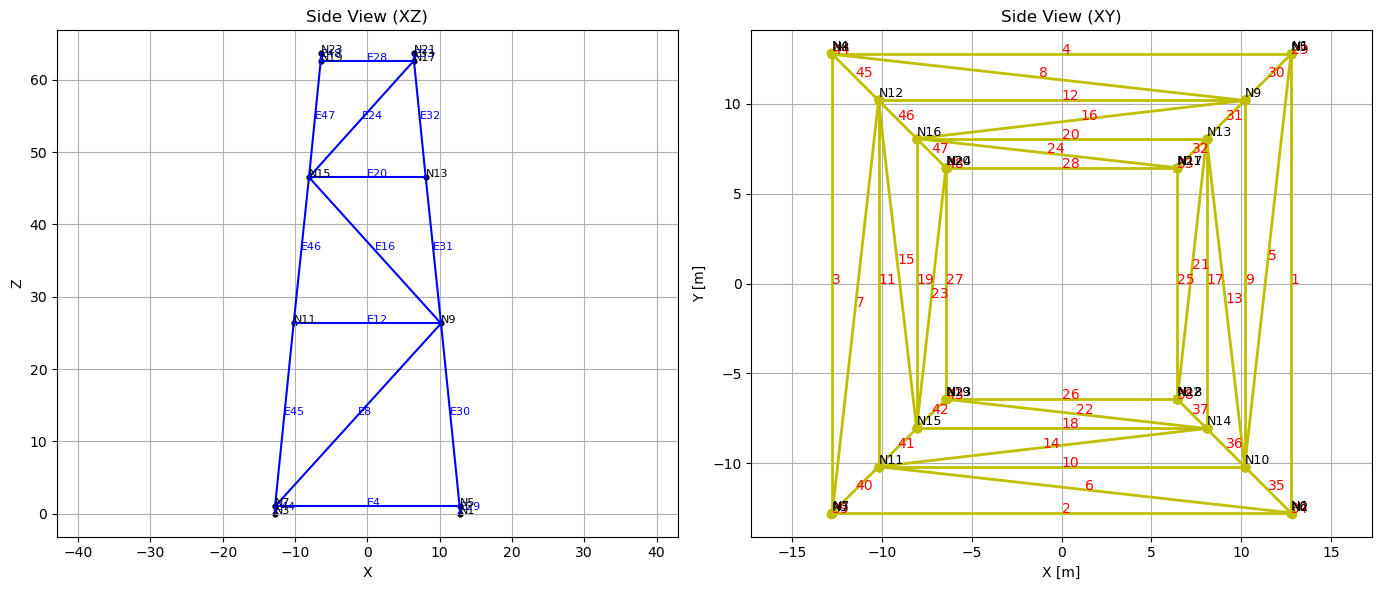

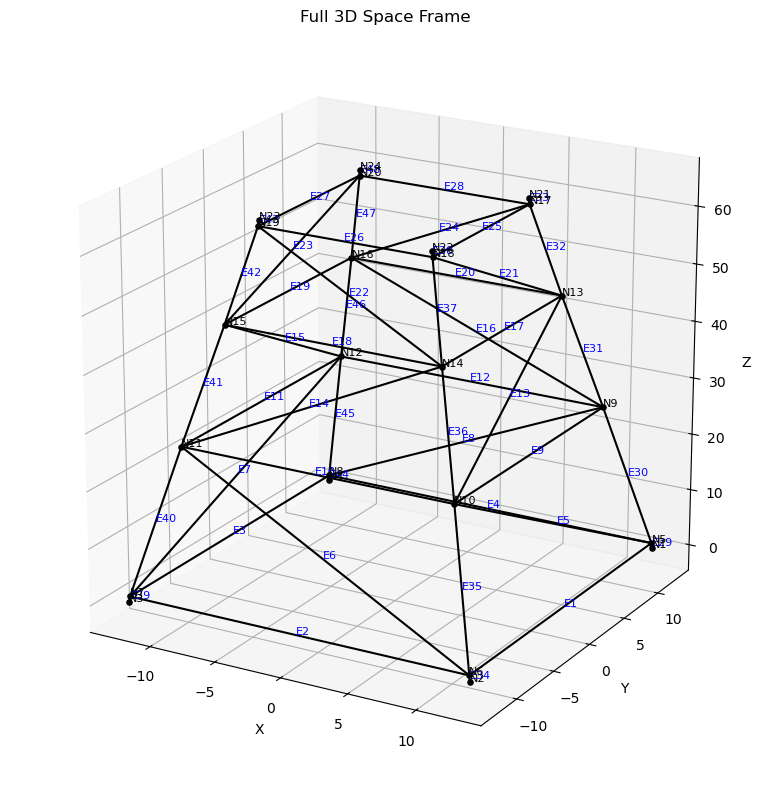

In [25]:

# Side views (XZ and XY) side by side
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

# Side view (XZ)
ax1.set_title("Side View (XZ)")
ax1.set_xlabel("X")
ax1.set_ylabel("Z")
ax1.axis("equal")
ax1.grid(True)

for elem in elements:
    if nodes_3d[elem["nodes"][0]][1] > 0 and nodes_3d[elem["nodes"][1]][1] > 0:
        n1, n2 = elem["nodes"]
        x1, y1, z1 = nodes_3d[n1]
        x2, y2, z2 = nodes_3d[n2]
        ax1.plot([x1, x2], [z1, z2], "b")
        xm, zm = (x1 + x2) / 2.0, (z1 + z2) / 2.0
        ax1.text(xm, zm, f"E{elem['id']}", color="blue", fontsize=8)

for nid, (x, y, z) in nodes_3d.items():
    if nid%2 == 1:
        ax1.scatter(x, z, c="black", s=12)
        ax1.text(x, z, f"N{nid}", color="black", fontsize=8)

# Side view (XY)
ax2.set_title("Side View (XY)")
ax2.set_xlabel("X [m]")
ax2.set_ylabel("Y [m]")
ax2.axis("equal")
ax2.grid(True)

for elem in elements:
    n1, n2 = elem["nodes"]
    x1, y1, z1 = nodes_3d[n1]
    x2, y2, z2 = nodes_3d[n2]
    ax2.plot([x1, x2], [y1, y2], "y-o", linewidth=2)
    xm, ym = (x1 + x2) / 2, (y1 + y2) / 2
    ax2.text(xm, ym, str(elem["id"]), color="red", fontsize=10)

for nid, (x, y, z) in nodes_3d.items():
    ax2.text(x, y, f"N{nid}", color="black", fontsize=9, verticalalignment="bottom")

plt.tight_layout()
plt.show()

# 3D view
fig3d = plt.figure(figsize=(10, 8))
ax3d = fig3d.add_subplot(111, projection="3d")

ax3d.set_title("Full 3D Space Frame")
ax3d.set_xlabel("X")
ax3d.set_ylabel("Y")
ax3d.set_zlabel("Z")

for elem in elements:
    n1, n2 = elem["nodes"]
    x1, y1, z1 = nodes_3d[n1]
    x2, y2, z2 = nodes_3d[n2]
    ax3d.plot([x1, x2], [y1, y2], [z1, z2], "k")
    xm, ym, zm = (x1 + x2) / 2.0, (y1 + y2) / 2.0, (z1 + z2) / 2.0
    ax3d.text(xm, ym, zm, f"E{elem['id']}", color="blue", fontsize=8)

for nid, (x, y, z) in nodes_3d.items():
    ax3d.scatter(x, y, z, c="black", s=14)
    ax3d.text(x, y, z, f"N{nid}", color="black", fontsize=8)

ax3d.set_box_aspect([1, 1, 1])
ax3d.view_init(elev=20, azim=-60)   # oblique view
plt.tight_layout()
plt.show()


### ELement overview

In [26]:

# Print element dimensions using values already computed above (no recalculation)
# Consolidate leg segments into one row per leg for display
_cols_first = ["Number", "Element type", "L_eff_m",
               "Chosen diameter (inches)", "Chosen thickness (inches)", "Inertia (inch4)"]
_cols_sum   = ["L_m", "Mass (t)", "Weight (kN)", "Buoyancy (kN)", "Subm. weight (kN)"]
_leg_agg = (
    out[out["Element type"] == "Leg"]
    .groupby("leg_id", sort=True)
    .agg(**{c: (c, "first") for c in _cols_first},
         **{c: (c, "sum")   for c in _cols_sum})
    .reset_index(drop=True)
)
_display = (
    pd.concat([_leg_agg, out[out["Element type"] != "Leg"]], ignore_index=True)
    .sort_values("Number")
    .reset_index(drop=True)
)

print("\nElement dimensions, thicknesses, weight and buoyancy:")
for _, row in _display.iterrows():
    print(
        f"Element {int(row['Number'])}: "
        f"Length: {row['L_m']:.3f} m, "
        f"Weight = {row['Weight (kN)']:.2f} kN, "
        f"Buoyancy = {row['Buoyancy (kN)']:.2f} kN, "
        f"Subm. weight = {row['Subm. weight (kN)']:.2f} kN"
    )



Element dimensions, thicknesses, weight and buoyancy:
Element 1: Length: 25.530 m, Weight = 59.77 kN, Buoyancy = 74.92 kN, Subm. weight = -15.15 kN
Element 2: Length: 25.530 m, Weight = 59.77 kN, Buoyancy = 74.92 kN, Subm. weight = -15.15 kN
Element 3: Length: 25.530 m, Weight = 59.77 kN, Buoyancy = 74.92 kN, Subm. weight = -15.15 kN
Element 4: Length: 25.530 m, Weight = 59.77 kN, Buoyancy = 74.92 kN, Subm. weight = -15.15 kN
Element 5: Length: 34.271 m, Weight = 213.97 kN, Buoyancy = 279.38 kN, Subm. weight = -65.42 kN
Element 6: Length: 34.271 m, Weight = 213.97 kN, Buoyancy = 279.38 kN, Subm. weight = -65.42 kN
Element 7: Length: 34.271 m, Weight = 213.97 kN, Buoyancy = 279.38 kN, Subm. weight = -65.42 kN
Element 8: Length: 34.271 m, Weight = 213.97 kN, Buoyancy = 279.38 kN, Subm. weight = -65.42 kN
Element 9: Length: 20.386 m, Weight = 31.82 kN, Buoyancy = 41.55 kN, Subm. weight = -9.73 kN
Element 10: Length: 20.386 m, Weight = 31.82 kN, Buoyancy = 41.55 kN, Subm. weight = -9.73 k

### Hydrodynamic loads and Stick model

#### General hydro part

In [27]:

# Hydrodynamic loads using Morrison's equation

H = 13.6 # wave height [m]
T = 15.0 # wave period [s]
z_MSL_abs = 52.0 # mean sea level absolute elevation [m above seabed]
phase = np.pi/4

rho = 1025
CD  = 0.7
CM  = 2

# ── Marine growth ─────────────────────────────────────────────────────────────
t_mg = 0.020 # marine growth thickness [m]
z_mg_bot = 0.0 # lower absolute elevation for marine growth [m above seabed]
z_mg_top = z_MSL_abs # upper absolute elevation for marine growth [m above seabed]

def hydro_diameter(D_struct, z_abs):
    """Structural diameter + marine growth if z_abs is within [z_mg_bot, z_mg_top]."""
    return D_struct + 2 * t_mg if z_mg_bot <= z_abs <= z_mg_top else D_struct

# Build members list from designed diameters — include element type for ring detection
_id_to_D_m = dict(zip(df["Number"], meters(df["Chosen diameter (inches)"])))# * 0.0254))
_id_to_type = dict(zip(df["Number"], df["Element type"]))
members_hydro = [
    {'start': e['nodes'][0], 'end': e['nodes'][1],
     'D': _id_to_D_m[e['id']], 'type': norm_type(e['type'])}
    for e in elements if e['id'] in _id_to_D_m
]
nodes = nodes_3d
members = members_hydro

z_levels_all = sorted({round(v[2], 3) for v in nodes.values()})

g = 9.81

def wave_number(T, h):
    omega = 2*np.pi/T
    k = (omega**2)/g
    for _ in range(10):
        f   = g*k*np.tanh(k*h) - omega**2
        df_ = g*np.tanh(k*h) + g*k*h*((1/np.cosh(k*h))**2)
        k  -= f/df_
    return k


def airy_kinematics(z, H, T, h, phase):
    omega = 2*np.pi/T
    k = wave_number(T, h)
    a = H/2
    u   = a*omega    * np.cosh(k*(z+h))/np.sinh(k*h) * np.cos(phase)
    a_x = a*omega**2 * np.cosh(k*(z+h))/np.sinh(k*h) * np.sin(phase)
    return u, a_x

def wheeler_z(z, zeta, h):
    return ((z+h)/(h+zeta))*h - h

# ── Wave properties ───────────────────────────────────────────────────────────
print(f"Wave parameters:  H = {H} m  |  T = {T} s  |  phase = {phase:.4f} rad")
print()
print(f"{'Water depth':>14}  {'k [rad/m]':>12}  {'λ = 2π/k [m]':>14}  {'kh':>8}  {'regime'}")
print("-" * 65)
for h_pr in [53.7, 50.5]:
    k_pr = wave_number(T, h_pr)
    lam = 2*np.pi / k_pr
    kh = k_pr * h_pr
    regime = "deep" if kh > np.pi else ("shallow" if kh < np.pi/10 else "intermediate")
    print(f"{h_pr:>14.1f}  {k_pr:>12.6f}  {lam:>14.3f}  {kh:>8.4f}  {regime}")


Wave parameters:  H = 13.6 m  |  T = 15.0 s  |  phase = 0.7854 rad

   Water depth     k [rad/m]    λ = 2π/k [m]        kh  regime
-----------------------------------------------------------------
          53.7      0.021727         289.192    1.1667  intermediate
          50.5      0.022158         283.568    1.1190  intermediate


#### Stick model

In [28]:
def stick_model(h, ranges, theta=0.0):
    """
    theta : wave heading angle [rad] from +X axis
            0        → straight (wave in +X)
            np.pi/4  → oblique  (wave at 45°)
    """
    zeta  = H/2 * np.cos(phase)
    k = wave_number(T, h)
    omega = 2*np.pi/T
    sin_t = np.sin(theta)
    cos_t = np.cos(theta)

    results = []

    for zL, zU in ranges:
        E0 = abs(zU - zL)
        Dde_sq_sum = 0.0 # accumulates D_de contributions
        Die_sq_sum = 0.0 # accumulates D_ie² contributions
        F_conc = 0.0 # concentrated force from horizontal members
        M_conc = 0.0 # moment contribution from concentrated forces

        for idx, m in enumerate(members):
            xi, yi, zi_raw = nodes[m['start']]
            xj, yj, zj_raw = nodes[m['end']]
            zi = zi_raw - h # relative to SWL
            zj = zj_raw - h

            z_lo_mbr = min(zi, zj)
            z_hi_mbr = max(zi, zj)

            # ── filter: must intersect this panel AND be below wave crest ──
            if z_lo_mbr > zeta: continue # entirely above crest
            if z_hi_mbr < zL - 1e-9: continue # entirely below panel
            if z_lo_mbr > zU + 1e-9: continue # entirely above panel

            dx = xj - xi
            dy = yj - yi
            dz_m = zj - zi
            L = np.sqrt(dx**2 + dy**2 + dz_m**2)
            if L == 0:
                continue

            # Component of member perpendicular to wave direction (horizontal plane)
            # dy_eff = -dx * sin_t + dy * cos_t
            dy_eff = dx * sin_t + dy * cos_t

            z_mid_abs = (zi_raw + zj_raw) / 2.0
            D_struct = m['D']
            D = hydro_diameter(D_struct, z_mid_abs)

            if abs(dz_m) < 1e-6:
                # horizontal member: concentrated force at its elevation
                # p_h_eff = silhouette width perpendicular to wave direction
                p_h_eff = abs(dy_eff)
                z_h = zi # relative to SWL
                if zL - 1e-9 <= z_h <= zU + 1e-9 and p_h_eff > 1e-9:
                    if z_h > zeta:
                        pass # above crest
                    else:
                        z_s_h = wheeler_z(z_h, zeta, h)
                        u_h, a_h = airy_kinematics(z_s_h, H, T, h, phase)
                        fh = (0.5*rho*CD*D*p_h_eff*u_h*abs(u_h)
                              + rho*CM*(np.pi/4)*D**2*p_h_eff*a_h)
                        F_conc += fh
                        M_conc += fh * z_h
            else:
                # inclined / vertical member: clip to panel
                z_lo_clip = max(zL, z_lo_mbr)
                z_hi_clip = min(zU, z_hi_mbr)
                dz_in = z_hi_clip - z_lo_clip
                if dz_in <= 0:
                    continue

                # projection in plane perpendicular to wave direction
                p_perp = np.sqrt(dy_eff**2 + dz_m**2)

                dDde = D * p_perp**2 * dz_in / (L * abs(dz_m) * E0)
                dDie_sq = D**2 * p_perp * dz_in / (abs(dz_m) * E0)

                Dde_sq_sum += dDde
                Die_sq_sum += dDie_sq

        Dde_sum = Dde_sq_sum
        Die_sum = np.sqrt(Die_sq_sum)

        # Simpson 3-point integration over the panel
        z_pts = [zU, (zU+zL)/2, zL]
        f_vals = []
        for z in z_pts:
            if z > zeta:
                f_vals.append(0.0) 
                continue
            z_s = wheeler_z(z, zeta, h)
            u, a_x = airy_kinematics(z_s, H, T, h, phase)
            f = 0.5*rho*CD*Dde_sum*u*abs(u) + rho*CM*(np.pi/4)*(Die_sum**2)*a_x
            f_vals.append(f)

        FR = E0/6*(f_vals[0] + 4*f_vals[1] + f_vals[2]) + F_conc
        MR = E0/6*(f_vals[0]*zU + 4*f_vals[1]*((zU+zL)/2) + f_vals[2]*zL) + M_conc

        results.append({'zU': zU, 'zL': zL, 'Force': FR, 'Moment_SWL': MR,
                        'Dde': Dde_sum, 'Die': Die_sum})

    F_total = sum(r['Force']      for r in results)
    M_total = sum(r['Moment_SWL'] for r in results)

    return F_total, M_total, results


#### Plot of stick model

In [29]:

h = 53.7 # Dmax case [m]
zeta_cr = H/2 * np.cos(phase)

# Find horizontal ring members (type == 'H') only
_all_hm = [
    m for m in members
    if m.get('type') == 'H'
    and abs(nodes[m['start']][2] - nodes[m['end']][2]) < 1e-6
    and nodes[m['start']][2] <= h + 1e-4
]
horiz_levels = sorted({round(nodes[m['start']][2], 3) for m in _all_hm})

def horiz_D_at(z_abs):
    """Max structural diameter of horizontal H-ring members at this elevation."""
    Ds = [m['D'] for m in _all_hm if abs(nodes[m['start']][2] - z_abs) < 0.01]
    return max(Ds) if Ds else 0.0

# Build 2*n+1 panels for n horizontal ring levels:
# seabed→H1_bot, H1_bot→H1_top, H1_top→H2_bot, ..., Hn_top→wave crest
print(f"Found {len(horiz_levels)} horizontal ring level(s) to {2*len(horiz_levels)+1} panels")

ranges = []
z_prev = -h # seabed, relative to SWL

for z_abs in horiz_levels:
    z_rel = z_abs - h
    D_h   = horiz_D_at(z_abs)
    z_bot = z_rel - D_h / 2
    z_top = z_rel + D_h / 2
    if z_prev < z_bot:
        ranges.append((z_prev, z_bot)) # panel below / between H members
    ranges.append((z_bot, z_top)) # panel centred on H member
    z_prev = z_top

if z_prev < zeta_cr:
    ranges.append((z_prev, zeta_cr)) # Hn_top to wave crest

print(f"Horizontal levels (abs): {horiz_levels}")
print(f"Number of panels : {len(ranges)}")
print()
print(f"{'Panel':>6}  {'zL (rel SWL)':>14}  {'zU (rel SWL)':>14}  {'zL_abs':>10}  {'zU_abs':>10}  {'h_panel':>9}  {'D_H [m]':>9}")
for i, (zL, zU) in enumerate(ranges):
    D_label = ""
    for z_abs in horiz_levels:
        if abs((zL + zU)/2 - (z_abs - h)) < 0.1:
            D_label = f"{horiz_D_at(z_abs):.4f}"
    print(f"{i+1:>6}  {zL:>14.3f}  {zU:>14.3f}  {zL+h:>10.3f}  {zU+h:>10.3f}  {zU-zL:>9.3f}  {D_label:>9}")

F_total, M_total, results_stick_model = stick_model(h, ranges)


print(f"\nWater surface acceleration : {airy_kinematics(zeta_cr, H, T, h, phase)[1]:.2f} m/s²")
print(f"\nWater surface velocity : {airy_kinematics(zeta_cr, H, T, h, phase)[0]:.2f} m/s")
print(f"\nEquivalent diameters and inertial diameters for all members:")
print(f"{'Panel':>6}  {'zL [m]':>9}  {'zU [m]':>9}  {'Dde [m]':>10}  {'Die [m]':>10}")
for i, r in enumerate(results_stick_model):
    print(f"{i+1:>6}  {r['zL']:>9.3f}  {r['zU']:>9.3f}  {r['Dde']:>10.4f}  {r['Die']:>10.4f}")
print(f"\nTotal horizontal force : {F_total/1e3:.2f} kN")
print(f"Total moment at SWL : {M_total/1e3:.2f} kN·m")
print()
for r in results_stick_model:
    print(f"  z=[{r['zL']:7.3f}, {r['zU']:7.3f}] m  "
          f"F={r['Force']/1e3:7.2f} kN  "
          f"M={r['Moment_SWL']/1e3:8.2f} kN·m  "
          f"Dde={r['Dde']:.4f} m  Die={r['Die']:.4f} m")


Found 3 horizontal ring level(s) to 7 panels
Horizontal levels (abs): [1.0, 26.314, 46.527]
Number of panels : 7

 Panel    zL (rel SWL)    zU (rel SWL)      zL_abs      zU_abs    h_panel    D_H [m]
     1         -53.700         -53.005       0.000       0.695      0.695           
     2         -53.005         -52.395       0.695       1.305      0.610     0.6096
     3         -52.395         -27.640       1.305      26.060     24.755           
     4         -27.640         -27.132      26.060      26.568      0.508     0.5080
     5         -27.132          -7.376      26.568      46.324     19.756           
     6          -7.376          -6.970      46.324      46.730      0.406     0.4064
     7          -6.970           4.808      46.730      58.508     11.778           

Water surface acceleration : 1.12 m/s²

Water surface velocity : 2.67 m/s

Equivalent diameters and inertial diameters for all members:
 Panel     zL [m]     zU [m]     Dde [m]     Die [m]
     1    -53.70

In [30]:

# Summary: Base shear & base moment for all load cases

def build_ranges(h_val):
    """Build 2*n+1 panels for n horizontal ring levels (type 'H') at water depth h_val."""
    zeta_cr = H/2 * np.cos(phase)
    _hm = [m for m in members
           if m.get('type') == 'H'
           and abs(nodes[m['start']][2] - nodes[m['end']][2]) < 1e-6
           and nodes[m['start']][2] <= h_val + 1e-4]
    h_levs = sorted({round(nodes[m['start']][2], 3) for m in _hm})

    def D_at(z_abs):
        Ds = [m['D'] for m in _hm if abs(nodes[m['start']][2] - z_abs) < 0.01]
        return max(Ds) if Ds else 0.0

    rng    = []
    z_prev = -h_val
    for z_abs in h_levs:
        z_rel = z_abs - h_val
        D_h   = D_at(z_abs)
        z_bot = z_rel - D_h / 2
        z_top = z_rel + D_h / 2
        if z_prev < z_bot:
            rng.append((z_prev, z_bot))
        rng.append((z_bot, z_top))
        z_prev = z_top
    if z_prev < zeta_cr:
        rng.append((z_prev, zeta_cr))
    return rng


load_cases = [
    (53.7, 'D_max = 53.7 m', 0.0,      'Straight (0°) '),
    (53.7, 'D_max = 53.7 m', np.pi/4,  'Oblique  (45°)'),
    (50.5, 'D_min = 50.5 m', 0.0,      'Straight (0°) '),
    (50.5, 'D_min = 50.5 m', np.pi/4,  'Oblique  (45°)'),
]

rows = []
for h_val, depth_lbl, theta_val, head_lbl in load_cases:
    rng = build_ranges(h_val)
    F, M_swl, _ = stick_model(h_val, rng, theta=theta_val)
    M_base = M_swl + F * h_val
    rows.append((depth_lbl, head_lbl, F/1e3, M_swl/1e3, M_base/1e3))

sep = "-" * 87
hdr = (f"{'Water depth':<17}  {'Wave heading':<15}  "
       f"{'Base shear':>13}  {'Moment @ SWL':>15}  {'Moment @ base':>15}")
print(sep)
print(hdr)
print(f"{'':17}  {'':15}  {'[MN]':>13}  {'[MN·m]':>15}  {'[MN·m]':>15}")
print(sep)
for depth_lbl, head_lbl, F_kN, M_swl_kN, M_base_kN in rows:
    print(f"{depth_lbl:<17}  {head_lbl:<15}  "
          f"{F_kN/1000:>13.2f}  {M_swl_kN/1000:>15.2f}  {M_base_kN/1000:>15.2f}")
print(sep)


---------------------------------------------------------------------------------------
Water depth        Wave heading        Base shear     Moment @ SWL    Moment @ base
                                             [MN]           [MN·m]           [MN·m]
---------------------------------------------------------------------------------------
D_max = 53.7 m     Straight (0°)             1.33           -30.17            41.43
D_max = 53.7 m     Oblique  (45°)            1.38           -31.64            42.46
D_min = 50.5 m     Straight (0°)             1.36           -28.89            40.00
D_min = 50.5 m     Oblique  (45°)            1.42           -30.34            41.14
---------------------------------------------------------------------------------------


#### Plot of hydrodynamic loading

NameError: name 'case_results' is not defined

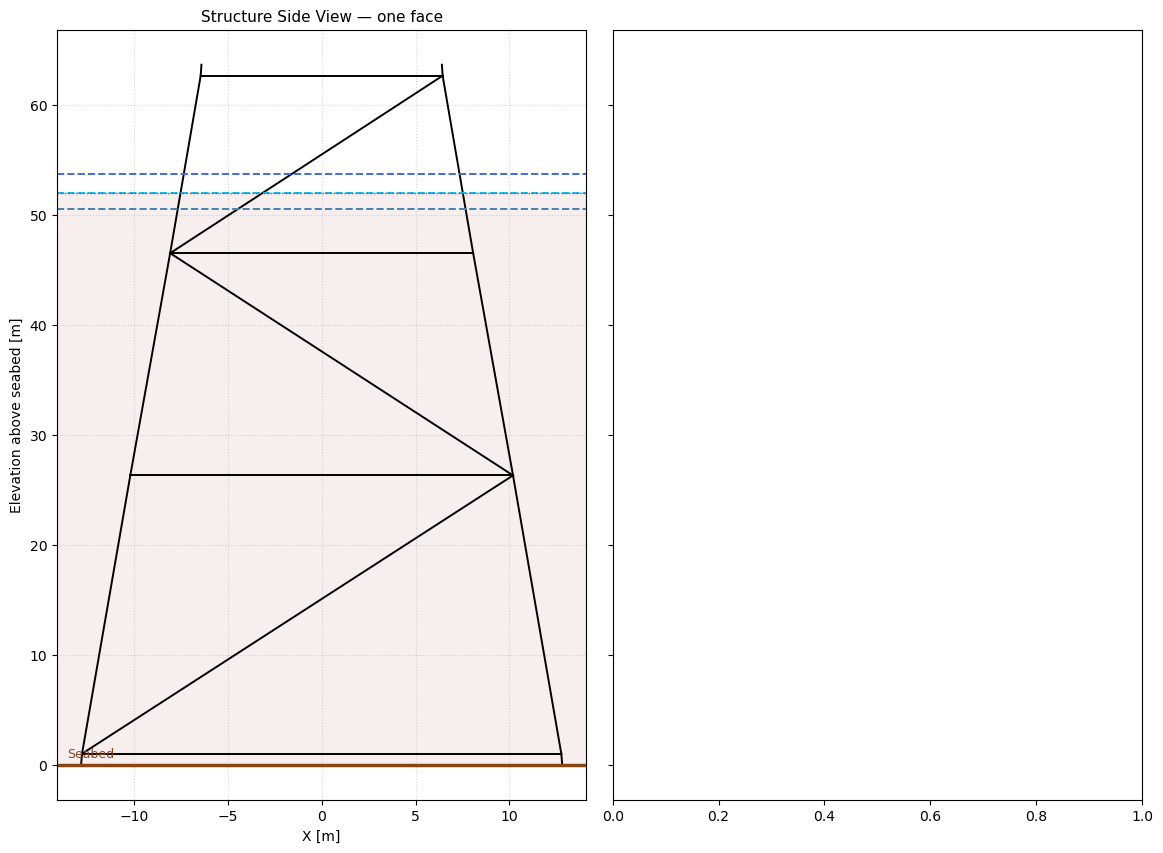

In [31]:
face_members = [
    m for m in members
    if nodes[m['start']][1] > 0 and nodes[m['end']][1] > 0
]

fig, (ax_s, ax_l) = plt.subplots(1, 2, figsize=(14, 10), sharey=True,
                                  gridspec_kw={'width_ratios': [1, 1]})
fig.subplots_adjust(wspace=0.05)

ax_s.set_title("Structure Side View — one face", fontsize=11)
ax_s.set_xlabel("X [m]")
ax_s.set_ylabel("Elevation above seabed [m]")
ax_s.grid(True, linestyle=':', alpha=0.5)

for m in face_members:
    x_i, y_i, z_i = nodes[m['start']]
    x_j, y_j, z_j = nodes[m['end']]
    ax_s.plot([x_i, x_j], [z_i, z_j], 'k-', linewidth=1.4)

ax_s.axhline(53.7,      color='royalblue',   linestyle='--', linewidth=1.4, label='SWL  D_max (53.7 m)')
ax_s.axhline(z_MSL_abs, color='deepskyblue', linestyle='--', linewidth=1.4, label=f'MSL ({z_MSL_abs:.0f} m)')
ax_s.axhline(50.5,      color='steelblue',   linestyle='--', linewidth=1.4, label='SWL  D_min (50.5 m)')
ax_s.axhspan(z_mg_bot, z_mg_top, alpha=0.08, color='brown',
             label=f'Marine growth [{z_mg_bot:.0f}–{z_mg_top:.0f} m]')
ax_s.axhline(z_mg_bot, color='sienna', linestyle=':', linewidth=1.0)
ax_s.axhline(z_mg_top, color='sienna', linestyle=':', linewidth=1.0)
ax_s.axhline(0, color='saddlebrown', linestyle='-', linewidth=2.5)
ax_s.text(0.02, 0.4, 'Seabed', transform=ax_s.get_yaxis_transform(),
          color='saddlebrown', fontsize=9, va='bottom')

for cr in case_results:
    z_crest_abs = cr['h'] + cr['zeta_cr']
    ax_s.axhline(z_crest_abs, color=cr['line_color'], linestyle='-.', linewidth=1.0,
                 alpha=0.8, label=f"Crest {cr['label']} ({z_crest_abs:.1f} m)")

all_horiz = sorted({z for cr in case_results for z in cr['horiz_abs']})
for z_hz in all_horiz:
    ax_s.axhline(z_hz, color='gray', linestyle='--', linewidth=0.8, alpha=0.6)

ax_s.legend(fontsize=8, loc='upper left')

ax_l.set_title("Hydrodynamic Load Distribution", fontsize=11)
ax_l.set_xlabel("Force per unit length [N/m]")
ax_l.grid(True, linestyle=':', alpha=0.5)
ax_l.axvline(0, color='k', linewidth=0.8)

for cr in case_results:
    fa = cr['forces'];  za = cr['z_abs']
    ax_l.fill_betweenx(za, -fa, fa, alpha=0.25, color=cr['fill_color'], step='mid')
    ax_l.step( fa, za, where='mid', color=cr['line_color'], linewidth=1.8, label=cr['label'])
    ax_l.step(-fa, za, where='mid', color=cr['line_color'], linewidth=1.8)

ax_l.axhline(53.7,      color='royalblue',   linestyle='--', linewidth=1.4, label='SWL  D_max (53.7 m)')
ax_l.axhline(z_MSL_abs, color='deepskyblue', linestyle='--', linewidth=1.4, label=f'MSL ({z_MSL_abs:.0f} m)')
ax_l.axhline(50.5,      color='steelblue',   linestyle='--', linewidth=1.4, label='SWL  D_min (50.5 m)')
ax_l.axhspan(z_mg_bot, z_mg_top, alpha=0.08, color='brown')
ax_l.axhline(0, color='saddlebrown', linestyle='-', linewidth=2.5)
ax_l.text(1.01, 0.4, 'Seabed', transform=ax_l.get_yaxis_transform(),
          color='saddlebrown', fontsize=9, va='bottom')

for cr in case_results:
    z_crest_abs = cr['h'] + cr['zeta_cr']
    ax_l.axhline(z_crest_abs, color=cr['line_color'], linestyle='-.', linewidth=1.0, alpha=0.8)

for z_hz in all_horiz:
    ax_l.axhline(z_hz, color='gray', linestyle='--', linewidth=0.8, alpha=0.7)
    ax_l.text(1.01, z_hz, f'z = {z_hz:.1f} m',
              transform=ax_l.get_yaxis_transform(),
              fontsize=7, color='dimgray', va='center')

ax_l.legend(fontsize=8, loc='upper left')
plt.suptitle('Hydrodynamic Loading — Morison Equation', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()


#  3D load-intensity plot
import matplotlib.cm as cm
from matplotlib.colors import Normalize

cr_plot     = case_results[0]
z_abs_plot  = cr_plot['z_abs']
forces_plot = cr_plot['forces']
h_plot      = cr_plot['h']

f_max = float(np.max(np.abs(forces_plot))) if np.max(np.abs(forces_plot)) > 0 else 1.0
norm  = Normalize(vmin=0, vmax=f_max)
cmap  = cm.plasma

fig3d_load = plt.figure(figsize=(12, 10))
ax3 = fig3d_load.add_subplot(111, projection='3d')
ax3.set_title('3D Structure — Hydrodynamic Load Intensity  (D$_{max}$ case)', fontsize=12)
ax3.set_xlabel('X [m]'); ax3.set_ylabel('Y [m]'); ax3.set_zlabel('Elevation [m]')

for m in members:
    xi, yi, zi_node = nodes[m['start']]
    xj, yj, zj_node = nodes[m['end']]
    z_mid_abs = (zi_node + zj_node) / 2.0
    f_mid  = float(np.interp(z_mid_abs, z_abs_plot, forces_plot, left=0.0, right=0.0))
    color  = cmap(norm(abs(f_mid)))
    ax3.plot([xi, xj], [yi, yj], [zi_node, zj_node], color=color, linewidth=2.5)

x_all = [nodes[n][0] for n in nodes]
y_all = [nodes[n][1] for n in nodes]
xx, yy = np.meshgrid([min(x_all), max(x_all)], [min(y_all), max(y_all)])
ax3.plot_surface(xx, yy, np.full_like(xx, h_plot), alpha=0.12, color='royalblue')

sm = cm.ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([])
cbar = fig3d_load.colorbar(sm, ax=ax3, shrink=0.5, pad=0.10)
cbar.set_label('Hydro force per unit length [N/m]', fontsize=9)

ax3.set_box_aspect([1, 1, 2])
ax3.view_init(elev=20, azim=-60)
plt.tight_layout()
# plt.show()

Vertical Loads

In [ ]:
# Vertical Loads — Nacelle & Rotor Eccentricity

print()
print("="*60)
print("VERTICAL LOADS & OVERTURNING MOMENTS")
print("="*60)
print()

# Data from IEA 15MW Manual
# Rotor specifications (m) 
rotor_diameter = 240.0
hub_diameter = 7.94
hub_overhang = 11.35 
blade_prebend = 4.0 

# Masses (tons)
mass_nacelle = 1017.0  
mass_rotor = 3*65.0
mass_tower = 860.0
g = 9.81  # m/s2

# Vertical loads (N)
W_nacelle = mass_nacelle * 1000 * g
W_rotor = mass_rotor * 1000 * g
W_tower = mass_tower * 1000 * g
W_total = W_nacelle + W_rotor + W_tower

# Eccentricity (horizontal offset of CoG from tower centerline), 
# inducing overturning moment from the nacelle and rotor weights.
# Eccentricity in m
ecc_nacelle = hub_overhang  # Nacelle center at hub overhang
ecc_rotor = hub_overhang + blade_prebend  # Rotor blades extend further by prebend

# Overturning moments
M_vertical_nacelle = W_nacelle * ecc_nacelle
M_vertical_rotor = W_rotor * ecc_rotor
M_vertical_total = M_vertical_nacelle + M_vertical_rotor

# Print results
print("WEIGHTS:")
print(f"Nacelle: {mass_nacelle:>7.0f} tons = {W_nacelle/1e6:.2f} MN")
print(f"Rotor: {mass_rotor:>7.0f} tons = {W_rotor/1e6:.2f} MN")
print(f"Tower: {mass_tower:>7.0f} tons = {W_tower/1e6:.2f} MN")
print(f"{'TOTAL':>8}  {(mass_nacelle+mass_rotor+mass_tower):>7.0f} tons = {W_total/1e6:.2f} MN")
print()

print("GEOMETRY:")
print(f"Rotor diameter = {rotor_diameter:.1f} m")
print(f"Hub diameter = {hub_diameter:.2f} m")
print(f"Hub overhang = {hub_overhang:.2f} m")
print(f"Blade prebend = {blade_prebend:.1f} m")
print()

print("OVERTURNING MOMENTS FROM OFFSET CoG:")
print(f"Nacelle CoG offset: {ecc_nacelle:.2f} m")
print(f"{W_nacelle/1e6:.2f} MN x {ecc_nacelle:.2f}m = {M_vertical_nacelle/1e6:.2f} MN m")
print()
print(f"Rotor CoG offset: {ecc_rotor:.2f} m")
print(f"{W_rotor/1e6:.2f} MN x {ecc_rotor:.2f}m = {M_vertical_rotor/1e6:.2f} MN m")
print()
print(f"{'TOTAL VERTICAL MOMENT':>30} = {M_vertical_total/1e6:.2f} MN m")
print()
print("="*60)
print()


VERTICAL LOADS & OVERTURNING MOMENTS

WEIGHTS:
Nacelle:    1017 tons = 9.98 MN
Rotor:     195 tons = 1.91 MN
Tower:     860 tons = 8.44 MN
   TOTAL     2072 tons = 20.33 MN

GEOMETRY:
Rotor diameter = 240.0 m
Hub diameter = 7.94 m
Hub overhang = 11.35 m
Blade prebend = 4.0 m

OVERTURNING MOMENTS FROM OFFSET CoG:
Nacelle CoG offset: 11.35 m
9.98 MN x 11.35m = 113.24 MN m

Rotor CoG offset: 15.35 m
1.91 MN x 15.35m = 29.36 MN m

         TOTAL VERTICAL MOMENT = 142.60 MN m




In [ ]:
# Aerodynamic loading

# Wind profile parameters (most of them assumed)
rho_air = 1.225 # kg/m³, air density at sea level
z_ref = 10.0 # m, reference height (standard value)
V_ref = 30.0 # m/s, wind speed at reference height
alpha = 0.13 # power law exponent 

# Elevation of hub above seabed (m)
z_hub = z_MSL_abs + h_hub  

# Function for the wind speed profile
def wind_speed_profile(z_abs, z_ref=z_ref, V_ref=V_ref, alpha=alpha, z_MSL=z_MSL_abs):
    if z_abs <= z_MSL:
        return 0.0  # No wind below sea level
    z_above_MSL = z_abs - z_MSL
    return V_ref * (z_above_MSL / z_ref) ** alpha

V_hub = wind_speed_profile(z_hub)

print(f"Wind profile parameters (all above seabed):")
print(f"Reference height z_ref = {z_ref} m")
print(f"Wind speed at z_ref = {V_ref} m/s")
print(f"Power-law exponent (a) = {alpha}")
print(f"Mean sea level (MSL) = {z_MSL_abs} m")
print(f"Hub height z_hub (abs) = {z_hub:.2f} m")
print(f"Wind speed at hub height  = {V_hub:.2f} m/s")
print()

# Wind speed distribution along structure height (above seabed)
z_heights = np.arange(z_MSL_abs, z_hub + 10, 5) # Extending 10 m to see the wind speed above the rotor
wind_speeds = np.array([wind_speed_profile(z) for z in z_heights])

print(f"{'Elevation [m]':>14}  {'Wind speed [m/s]':>17}")
print("-" * 35)
for z, V in zip(z_heights[::4], wind_speeds[::5]):
    print(f"{z:>14.1f}  {V:>17.2f}")
print()


# Aerodynamic drag on surfaces (it's different coefficients for different geometries).
# The values as mostly chosen by us, since we didn't have available data.

# Tower (m)
tower_diam = 10.0
CD_tower = 0.7 # drag coefficient (smooth cylinder)
CM_tower = 1.0 # inertia coefficient (cylinder)
A_tower = np.pi * tower_diam * (z_hub - z_MSL_abs)

# Nacelle (m)
nacelle_width = 10.6
nacelle_height = 5.7
A_nacelle = nacelle_width * nacelle_height
CD_nacelle = 1.0
CM_nacelle = 1.0

# Rotor (m)
rotor_diameter = 240.0
rotor_radius = rotor_diameter / 2
hub_diameter = 7.94
hub_overhang = 11.35
blade_prebend = 4.0
# We chose smalled CD and CM for the rotor since blades
# are pitched to 90 degrees in extreme conditions, and thus
# contributing very little in drag and inertial properties.
CD_rotor_feathered = 0.2
CM_rotor_feathered = 0.4
rotor_swept_area = np.pi * rotor_radius**2
rotor_hub_area = np.pi * (hub_diameter/2)**2
rotor_effective_frontal = rotor_hub_area


print(f"Exposed aerodynamic areas for each member")
print(f"Tower (above MSL):")
print(f"Diameter = {tower_diam} m, Height = {z_hub - z_MSL_abs:.1f} m")
print(f"Projected area A_tower = π x {tower_diam} x {z_hub - z_MSL_abs:.1f} = {A_tower:.1f} m2")
print(f"Drag coeff CD = {CD_tower} (smooth cylinder), Inertia CM = {CM_tower}")
print()
print(f"Nacelle/hub assembly:")
print(f"Width x Height = {nacelle_width} x {nacelle_height} = {A_nacelle:.1f} m2")
print(f"Drag coeff CD = {CD_nacelle}, Inertia CM = {CM_nacelle} (bluff body)")
print()
print(f"Rotor blades (at hub z = {z_hub:.1f} m):")
print(f"Diameter = {rotor_diameter:.1f} m, Radius = {rotor_radius:.1f} m")
print(f"Hub diameter = {hub_diameter:.2f} m, Hub overhang = {hub_overhang:.2f} m")
print(f"Blade prebend = {blade_prebend:.1f} m")
print(f"Swept area (reference) = {rotor_swept_area:.0f} m2")
print(f"Effective frontal area (feathered) = {rotor_effective_frontal:.1f} m2 (hub + spinner only)")
print(f"Drag coeff CD = {CD_rotor_feathered} (edge-on, minimal), Inertia CM = {CM_rotor_feathered}")
print()



Wind profile parameters (all above seabed):
Reference height z_ref = 10.0 m
Wind speed at z_ref = 30.0 m/s
Power-law exponent (a) = 0.13
Mean sea level (MSL) = 52.0 m
Hub height z_hub (abs) = 202.00 m
Wind speed at hub height  = 42.66 m/s

 Elevation [m]   Wind speed [m/s]
-----------------------------------
          52.0               0.00
          72.0              33.80
          92.0              36.98
         112.0              38.98
         132.0              40.47
         152.0              41.66
         172.0              42.66

Exposed aerodynamic areas for each member
Tower (above MSL):
Diameter = 10.0 m, Height = 150.0 m
Projected area A_tower = π x 10.0 x 150.0 = 4712.4 m2
Drag coeff CD = 0.7 (smooth cylinder), Inertia CM = 1.0

Nacelle/hub assembly:
Width x Height = 10.6 x 5.7 = 60.4 m2
Drag coeff CD = 1.0, Inertia CM = 1.0 (bluff body)

Rotor blades (at hub z = 202.0 m):
Diameter = 240.0 m, Radius = 120.0 m
Hub diameter = 7.94 m, Hub overhang = 11.35 m
Blade prebend

AERODYNAMIC LOADS:
Tower distributed force =       0.94 MN
Nacelle concentrated force =     0.0673 MN
Rotor blades (feathered) =     0.0110 MN
Total horizontal force =       1.02 MN

Moment from tower (at the base) =     129.67 MN m
Moment from nacelle =    13.6039 MN m
Moment from rotor =     2.2297 MN m
Total moment at the base =     145.51 MN m

  Height [m]   Wind speed [m/s]    Force/m [N/m]
--------------------------------------------------
        52.0               0.00                0
        62.0              30.00             3859
        72.0              32.83             4621
        82.0              34.61             5135
        92.0              35.92             5533
       102.0              36.98             5864
       112.0              37.87             6148
       122.0              38.64             6400
       132.0              39.31             6626
       142.0              39.92             6832
       152.0              40.47             7022
       162

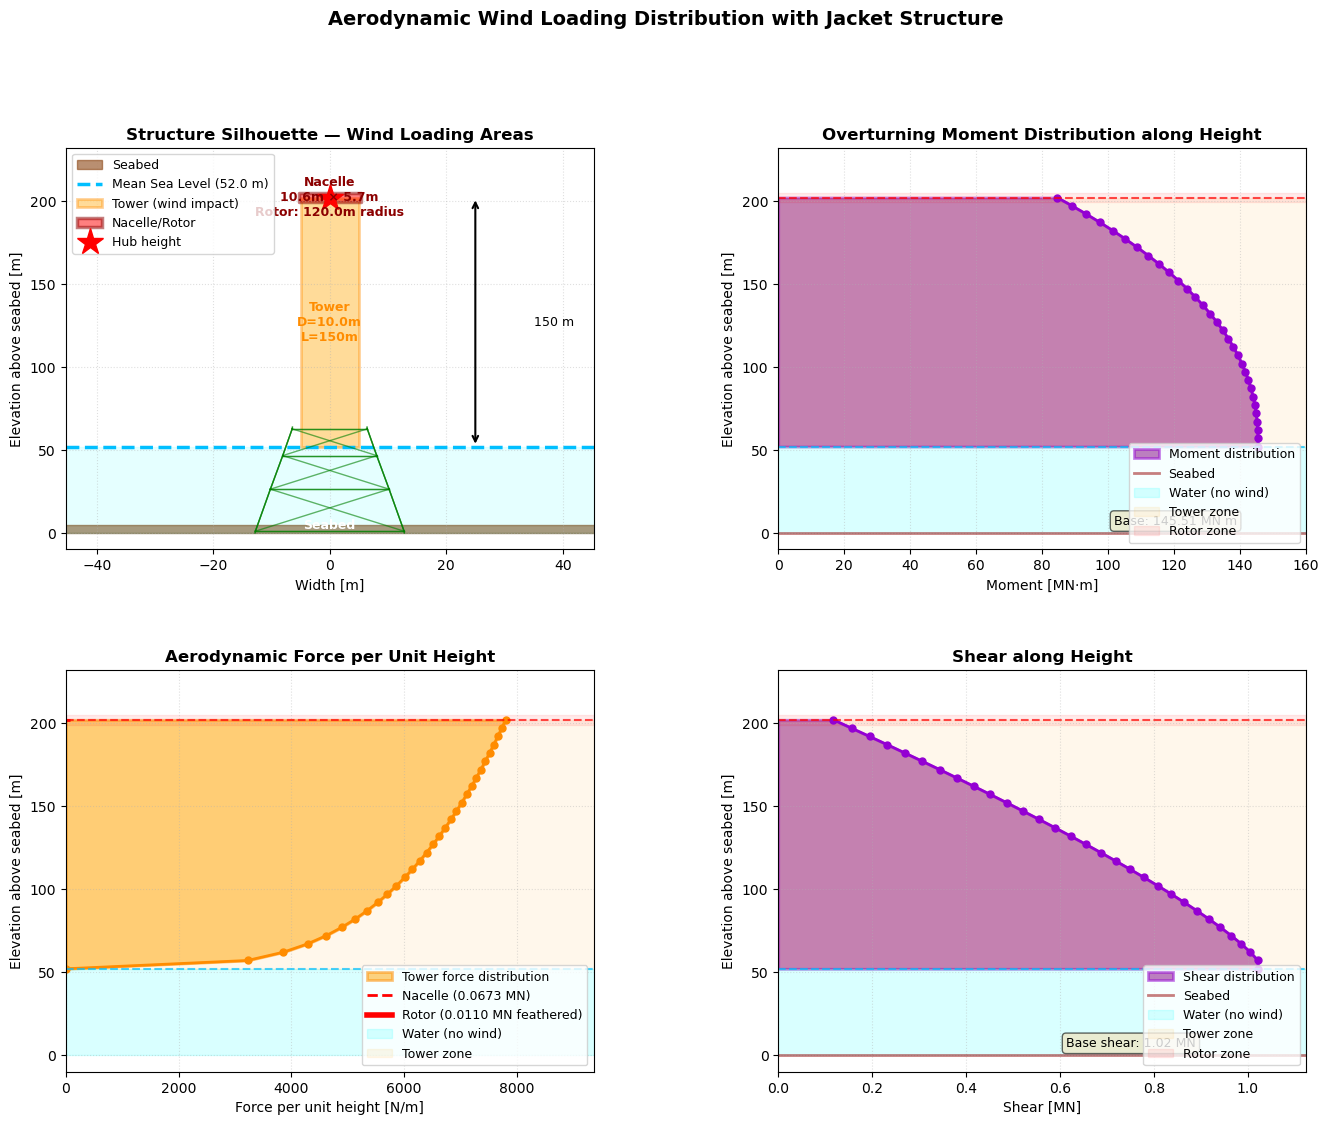

In [ ]:
# Aerodynamic force distribution along height
# For tower: F_tower(z) = 0.5*ρ*CD_tower*tower_diam*V(z)2 per unit height
# For nacelle: F_nacelle = 0.5*ρ*CD_nacelle*A_nacelle*V_hub2
# For rotor (feathered): F_rotor = 0.5*ρ*CD_rotor_feathered*A_rotor_eff*V_hub2

dz_wind = 5.0  # resolution for wind force distribution [m]
z_wind_dist = np.arange(z_MSL_abs, z_hub + dz_wind, dz_wind)

# Force per unit height on tower above MSL (N/m)
f_tower_per_m = []
for z in z_wind_dist:
    V_z = wind_speed_profile(z)
    f = 0.5 * rho_air * CD_tower * tower_diam * V_z**2
    f_tower_per_m.append(f)
f_tower_per_m = np.array(f_tower_per_m)

# Wind speeds at key elevations
V_hub_val = wind_speed_profile(z_hub)
V_nacelle = V_hub_val  # nacelle is at the hub height

# Force on nacelle at hub height (concentrated) in N
F_nacelle = 0.5 * rho_air * CD_nacelle * A_nacelle * V_nacelle**2

# Force on rotor blades in N
F_rotor = 0.5 * rho_air * CD_rotor_feathered * rotor_effective_frontal * V_hub_val**2

# Total wind forces (N)
F_wind_tower = np.sum(f_tower_per_m) * dz_wind
F_wind_total = F_wind_tower + F_nacelle + F_rotor

# Moment at base (N m)
# As explained earlier, we account for the
# distributed tower load + concentrated nacelle + rotor loads
M_wind_tower = 0.0
for i, z in enumerate(z_wind_dist):
    z_lever = z
    M_wind_tower += f_tower_per_m[i] * z_lever * dz_wind
M_nacelle = F_nacelle * z_hub
M_rotor = F_rotor * z_hub
M_wind_total = M_wind_tower + M_nacelle + M_rotor

print(f"AERODYNAMIC LOADS:")
print(f"Tower distributed force = {F_wind_tower/1e6:>10.2f} MN")
print(f"Nacelle concentrated force = {F_nacelle/1e6:>10.4f} MN")
print(f"Rotor blades (feathered) = {F_rotor/1e6:>10.4f} MN")
print(f"Total horizontal force = {F_wind_total/1e6:>10.2f} MN")
print()
print(f"Moment from tower (at the base) = {M_wind_tower/1e6:>10.2f} MN m")
print(f"Moment from nacelle = {M_nacelle/1e6:>10.4f} MN m")
print(f"Moment from rotor = {M_rotor/1e6:>10.4f} MN m")
print(f"Total moment at the base = {M_wind_total/1e6:>10.2f} MN m")
print()

# Print wind speed and force distribution at key heights
print(f"{'Height [m]':>12}  {'Wind speed [m/s]':>17}  {'Force/m [N/m]':>15}")
print("-" * 50)
for z, f in zip(z_wind_dist[::2], f_tower_per_m[::2]):
    V_z = wind_speed_profile(z)
    print(f"{z:>12.1f}  {V_z:>17.2f}  {f:>15.0f}")
print(f"{'Hub':>12}  {wind_speed_profile(z_hub):>17.2f}  {'(nacelle/rotor)':>15}")
print()

# Summary: Aerodynamic base shear and moment
print("=" * 85)
print("WIND LOADING SUMMARY — Base shear and moment at seabed (z = 0)")
print("=" * 85)
print(f"Wind condition: Extreme/survival at {V_ref} m/s @ {z_ref}m height")
print(f"Wind profile exponent α = {alpha} (offshore)")
print(f"Wind acts only above MSL (z ≥ {z_MSL_abs} m)")
print()
print(f"{'Load source':<30}  {'Base shear':>16}  {'Moment @ base':>18}")
print(f"{'':30}  {'[MN]':>16}  {'[GN·m]':>18}")
print("-" * 85)
print(f"{'Tower (distributed)':30}  {F_wind_tower/1e6:>16.2f}  {M_wind_tower/1e9:>18.2f}")
print(f"{'Nacelle (concentrated)':30}  {F_nacelle/1e6:>16.4f}  {M_nacelle/1e9:>18.4f}")
print(f"{'Rotor (feathered blades)':30}  {F_rotor/1e6:>16.4f}  {M_rotor/1e9:>18.4f}")
print("-" * 85)
print(f"{'TOTAL AERODYNAMIC':30}  {F_wind_total/1e6:>16.2f}  {M_wind_total/1e9:>18.2f}")
print("-" * 85)

# Combine loading 
print()
print("=" * 85)
print("COMBINED LOAD COMPARISON")
print("=" * 85)
print()

# Get hydrodynamic loads from the D_max case at 0° heading
h_hydro = 53.7
rng_hydro = build_ranges(h_hydro)
F_hydro, M_swl_hydro, _ = stick_model(h_hydro, rng_hydro, theta=0.0)
M_base_hydro = M_swl_hydro + F_hydro * h_hydro

print(f"{'Load case':<30}  {'Base shear':>16}  {'Moment at base':>18}")
print(f"{'':30}  {'[MN]':>16}  {'[GN·m]':>18}")
print("-" * 85)
print(f"{'Hydrodynamic (D_max, 0°)':30}  {F_hydro/1e6:>16.2f}  {M_base_hydro/1e9:>18.2f}")
print(f"{'Aerodynamic':30}  {F_wind_total/1e6:>16.2f}  {M_wind_total/1e9:>18.2f}")
print("-" * 85)
F_combined = F_hydro + F_wind_total
M_combined = M_base_hydro + M_wind_total
print(f"{'COMBINED (Hydro + Aero)':30}  {F_combined/1e6:>16.2f}  {M_combined/1e9:>18.2f}")





# Plotting the aerodynamic distribution
fig, ((ax_struct, ax_wind), (ax_force, ax_impact)) = plt.subplots(
    2, 2, figsize=(16, 12), gridspec_kw={'hspace': 0.3, 'wspace': 0.35})

# TOP left: display the structure's silhouette 
ax_struct.set_title("Structure Silhouette — Wind Loading Areas", fontsize=12, fontweight='bold')
ax_struct.set_xlabel("Width [m]")
ax_struct.set_ylabel("Elevation above seabed [m]")
ax_struct.grid(True, linestyle=':', alpha=0.4)

# seabed
ax_struct.fill_between([-500, 500], 0, 5, color='saddlebrown', alpha=0.6, label='Seabed')
ax_struct.text(0, 2.5, 'Seabed', ha='center', fontsize=9, color='white', weight='bold')

# MSL
ax_struct.axhline(z_MSL_abs, color='deepskyblue', linestyle='--', linewidth=2.5, label=f'Mean Sea Level ({z_MSL_abs} m)')
ax_struct.fill_between([-500, 500], 0, z_MSL_abs, color='cyan', alpha=0.1)


# Tower
tower_radius = tower_diam / 2 
ax_struct.fill_between([-tower_radius, tower_radius], z_MSL_abs, z_hub,
                       color='orange', alpha=0.4, edgecolor='darkorange', linewidth=2, label='Tower (wind impact)')
ax_struct.text(0, (z_MSL_abs + z_hub)/2, f'Tower\nD={tower_diam}m\nL={z_hub-z_MSL_abs:.0f}m',
              ha='center', va='center', fontsize=9, weight='bold', color='darkorange')

# Rotor/blades and nacelle
nacelle_half_width = nacelle_width / 2
nacelle_half_height = nacelle_height / 2
ax_struct.fill_between([-nacelle_half_width, nacelle_half_width], 
                       z_hub - nacelle_half_height, z_hub + nacelle_half_height,
                       color='red', alpha=0.5, edgecolor='darkred', linewidth=2.5, label='Nacelle/Rotor')
ax_struct.text(0, z_hub, f'Nacelle\n{nacelle_width}m × {nacelle_height}m\nRotor: {np.sqrt(rotor_swept_area/np.pi):.1f}m radius',
              ha='center', va='center', fontsize=9, weight='bold', color='darkred')

# Hub location
ax_struct.plot(0, z_hub, 'r*', markersize=20, label='Hub height')

# Annotations
ax_struct.annotate('', xy=(tower_radius + 20, z_MSL_abs), xytext=(tower_radius + 20, z_hub),
                  arrowprops=dict(arrowstyle='<->', color='black', lw=1.5))
ax_struct.text(tower_radius + 30, (z_MSL_abs + z_hub)/2, f'{z_hub - z_MSL_abs:.0f} m',
              fontsize=9, va='center')

# Overlay jacket stick model (side view) on structure silhouette
for elem in elements:
    n1_id, n2_id = elem['nodes']
    
    # Get node coordinates
    if n1_id in nodes_3d and n2_id in nodes_3d:
        x1, y1, z1 = nodes_3d[n1_id]
        x2, y2, z2 = nodes_3d[n2_id]
        
        # Plot jacket members (X-Z plane side view) with thin green line
        ax_struct.plot([x1, x2], [z1, z2], 'g-', linewidth=1.0, alpha=0.6, zorder=5)

ax_struct.set_xlim(-nacelle_half_width - 40, nacelle_half_width + 40)
ax_struct.set_ylim(-10, z_hub + 30)
ax_struct.legend(fontsize=9, loc='upper left')
ax_struct.set_aspect('auto')


# TOP right: Moment distribution along height
ax_wind.set_title("Overturning Moment Distribution along Height", fontsize=12, fontweight='bold')
ax_wind.set_xlabel("Moment [MN·m]")
ax_wind.set_ylabel("Elevation above seabed [m]")
ax_wind.grid(True, linestyle=':', alpha=0.4)

# Calculate moment distribution from base upward
# Consider M(z) the integral of forces above z, multiplied by their lever arms
moment_dist = np.zeros_like(z_wind_dist)
for i, z in enumerate(z_wind_dist):
    # Moment from tower forces above this height
    moment_dist[i] = M_wind_tower
    # Subtract moment from forces below this height (forces below don't contribute above)
    for j in range(i):
        moment_dist[i] -= f_tower_per_m[j] * (z - z_wind_dist[j]) * dz_wind

# Add concentrated moments from nacelle and rotor where applicable
for i, z in enumerate(z_wind_dist):
    if z <= z_hub:
        moment_dist[i] += M_nacelle + M_rotor

# Plot moment distribution
ax_wind.fill_betweenx(z_wind_dist, 0, moment_dist/1e6, alpha=0.5, color='purple', 
                       edgecolor='darkviolet', linewidth=2, label='Moment distribution')
ax_wind.plot(moment_dist/1e6, z_wind_dist, 'o-', color='darkviolet', markersize=5, linewidth=2)

# Mark base moment
ax_wind.axhline(0, color='brown', linestyle='-', linewidth=2, alpha=0.6, label='Seabed')
ax_wind.text(M_wind_total/1e6 * 0.7, 5, f'Base: {M_wind_total/1e6:.2f} MN m', fontsize=9, 
            bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.6))

# Zones
ax_wind.axhspan(0, z_MSL_abs, alpha=0.15, color='cyan', label='Water (no wind)')
ax_wind.axhspan(z_MSL_abs, z_hub, alpha=0.08, color='orange', label='Tower zone')
ax_wind.axhspan(z_hub - nacelle_height/2, z_hub + nacelle_height/2, alpha=0.08, color='red', label='Rotor zone')

# MSL and hub lines
ax_wind.axhline(z_MSL_abs, color='deepskyblue', linestyle='--', linewidth=1.5, alpha=0.7)
ax_wind.axhline(z_hub, color='red', linestyle='--', linewidth=1.5, alpha=0.7)

ax_wind.set_xlim(0, M_wind_total/1e6 * 1.1)
ax_wind.set_ylim(-10, z_hub + 30)
ax_wind.legend(fontsize=9, loc='lower right')


# BOTTOM right: Shear distribution along height
ax_impact.set_title("Shear along Height", fontsize=12, fontweight='bold')
ax_impact.set_xlabel("Shear [MN]")
ax_impact.set_ylabel("Elevation above seabed [m]")
ax_impact.grid(True, linestyle=':', alpha=0.4)

# Initialize shear distribution
shear_dist = np.zeros_like(z_wind_dist)

# Compute shear from top downward
for i, z in enumerate(z_wind_dist):

    # distributed tower loads ABOVE this height
    shear_dist[i] = np.sum(f_tower_per_m[i:]) * dz_wind

    # add nacelle + rotor forces if above this point
    if z <= z_hub:
        shear_dist[i] += F_nacelle + F_rotor

# Plot shear distribution
ax_impact.fill_betweenx(z_wind_dist, 0, shear_dist/1e6, alpha=0.5, color='purple',
    edgecolor='darkviolet', linewidth=2, label='Shear distribution')
ax_impact.plot(shear_dist/1e6, z_wind_dist, 'o-',
    color='darkviolet', markersize=5, linewidth=2)

# Seabed
ax_impact.axhline(0, color='brown', linestyle='-', linewidth=2, alpha=0.6, label='Seabed')

# Base shear label
ax_impact.text(shear_dist[0]/1e6 * 0.6, 5, f'Base shear: {shear_dist[0]/1e6:.2f} MN',
    fontsize=9, bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.6))

# Zones
ax_impact.axhspan(0, z_MSL_abs, alpha=0.15, color='cyan', label='Water (no wind)')
ax_impact.axhspan(z_MSL_abs, z_hub, alpha=0.08, color='orange', label='Tower zone')
ax_impact.axhspan(z_hub - nacelle_height/2, z_hub + nacelle_height/2, alpha=0.08, color='red', label='Rotor zone')

# Reference lines
ax_impact.axhline(z_MSL_abs, color='deepskyblue', linestyle='--', linewidth=1.5, alpha=0.7)
ax_impact.axhline(z_hub, color='red', linestyle='--', linewidth=1.5, alpha=0.7)

ax_impact.set_xlim(0, shear_dist[0]/1e6 * 1.1)
ax_impact.set_ylim(-10, z_hub + 30)
ax_impact.legend(fontsize=9, loc='lower right')


# BOTTOM left: Force distribution 
ax_force.set_title("Aerodynamic Force per Unit Height", fontsize=12, fontweight='bold')
ax_force.set_xlabel("Force per unit height [N/m]")
ax_force.set_ylabel("Elevation above seabed [m]")
ax_force.grid(True, linestyle=':', alpha=0.4)

# Plot force distribution on tower
ax_force.fill_betweenx(z_wind_dist, 0, f_tower_per_m, alpha=0.5, color='orange', 
                       edgecolor='darkorange', linewidth=2, label='Tower force distribution')
ax_force.plot(f_tower_per_m, z_wind_dist, 'o-', color='darkorange', markersize=5, linewidth=2)

# Add concentrated nacelle and rotor forces as spikes
ax_force.plot([0, F_nacelle/1e3], [z_hub, z_hub], 
             'r--', linewidth=2, label=f'Nacelle ({F_nacelle/1e6:.4f} MN)')
ax_force.plot([F_nacelle/1e3, F_nacelle/1e3 + F_rotor/1e3], [z_hub, z_hub], 
             'r-', linewidth=4, label=f'Rotor ({F_rotor/1e6:.4f} MN feathered)')

# Zones
ax_force.axhspan(0, z_MSL_abs, alpha=0.15, color='cyan', label='Water (no wind)')
ax_force.axhspan(z_MSL_abs, z_hub, alpha=0.08, color='orange', label='Tower zone')
ax_force.axhspan(z_hub - nacelle_height/2, z_hub + nacelle_height/2, alpha=0.08, color='red')

# MSL and hub lines
ax_force.axhline(z_MSL_abs, color='deepskyblue', linestyle='--', linewidth=1.5, alpha=0.7)
ax_force.axhline(z_hub, color='red', linestyle='--', linewidth=1.5, alpha=0.7)

# ax_force.text(max(f_tower_per_m) * 0.1, z_MSL_abs - 3, 'SEA LEVEL', fontsize=10, ha='left', weight='bold', color='darkblue')

ax_force.set_xlim(0, max(f_tower_per_m) * 1.2)
ax_force.set_ylim(-10, z_hub + 30)
ax_force.legend(fontsize=9, loc='lower right')


plt.suptitle('Aerodynamic Wind Loading Distribution with Jacket Structure', fontsize=14, fontweight='bold', y=0.995)
plt.tight_layout()
# plt.show()



In [ ]:
# Combined Load Scenarios — All Cases & Combinations

print()
print("="*80)
print("COMBINED LOAD ANALYSIS")
print("="*80)
print()

# Define all 4 hydrodynamic cases
hydro_cases = [
    {"name": "D_max (53.7m) — 0 deg",  "diameter": 53.7, "theta": 0.0},
    {"name": "D_max (53.7m) — 45 deg", "diameter": 53.7, "theta": np.pi/4},
    {"name": "D_min (50.5m) — 0 deg",  "diameter": 50.5, "theta": 0.0},
    {"name": "D_min (50.5m) — 45 deg", "diameter": 50.5, "theta": np.pi/4},
]

combined_results = []

for case in hydro_cases:
    h_wl = case["diameter"]
    rng  = build_ranges(h_wl)
    F_h, M_swl, _ = stick_model(h_wl, rng, theta=case["theta"])
    M_h_base   = M_swl + F_h * h_wl
    F_combined = F_h + F_wind_total
    M_combined = M_h_base + M_wind_total + M_vertical_total
    combined_results.append({
        "case":       case["name"],
        "F_hydro":    F_h,
        "M_hydro":    M_h_base,
        "F_aero":     F_wind_total,
        "M_aero":     M_wind_total,
        "M_vertical": M_vertical_total,
        "F_combined": F_combined,
        "M_combined": M_combined,
    })

# Identify governing cases 
max_shear_case  = max(combined_results, key=lambda x: x["F_combined"])
max_moment_case = max(combined_results, key=lambda x: x["M_combined"])

# Design Combination 1: Maximum base shear + accompanying moment 
print("DESIGN COMBINATION 1: Maximum base shear")
print("-"*55)
print(f"  Governing case      : {max_shear_case['case']}")
print(f"  Base shear   [MN]   : {max_shear_case['F_combined']/1e6:>8.2f}")
print(f"  Base moment  [MN·m] : {max_shear_case['M_combined']/1e6:>8.2f}")
print()

# Design Combination 2: Maximum base moment + accompanying shear 
print("DESIGN COMBINATION 2: Maximum base moment")
print("-"*55)
print(f"  Governing case      : {max_moment_case['case']}")
print(f"  Base moment  [MN·m] : {max_moment_case['M_combined']/1e6:>8.2f}")
print(f"  Base shear   [MN]   : {max_moment_case['F_combined']/1e6:>8.2f}")
print()

print("="*80)



COMBINED LOAD ANALYSIS

DESIGN COMBINATION 1: Maximum base shear
-------------------------------------------------------
  Governing case      : D_min (50.5m) — 45 deg
  Base shear   [MN]   :     2.44
  Base moment  [MN·m] :   329.24

DESIGN COMBINATION 2: Maximum base moment
-------------------------------------------------------
  Governing case      : D_max (53.7m) — 45 deg
  Base moment  [MN·m] :   330.57
  Base shear   [MN]   :     2.40



### Piles

In [ ]:
## Pile reactions

# Pile geometry 
D_o_in = out.loc[out["Element type"] == "Leg", "Chosen diameter (inches)"].iloc[0]
t_in   = out.loc[out["Element type"] == "Leg", "Chosen thickness (inches)"].iloc[0]
D_o = meters(D_o_in)
t   = meters(t_in)
D_i = D_o - 2 * t
A_steel = (np.pi / 4) * (D_o**2 - D_i**2)
A_tip   = np.pi * (D_o - t) * t   # assumed unplugged
alpha = np.arctan(1/10)   # [rad]

# Find rotation pole height (C)
leg_nodes_1 = sorted(
    set(n for e in elements if e.get('leg_id') == 1 for n in e['nodes']),
    key=lambda n: nodes_3d[n][2]
)
x_bot = abs(nodes_3d[leg_nodes_1[0]][0])
x_top = abs(nodes_3d[leg_nodes_1[-1]][0])
z_top = nodes_3d[leg_nodes_1[-1]][2]
h_c = z_top + x_top / np.tan(alpha)   # [m] above mudline
d_e = 3 * D_o   # [m]

# Partial load factors 
gG_a, gQ_a, gE_a = 1.35, 1.1, 1.1   # extreme – additive   (compression governs)
gG_o, gQ_o, gE_o = 1.35, 0.8, 0.9   # extreme – opposing   (tension/uplift check)

# Characteristic loads by action category 
W_jacket  = W_sub_total * 1e3   # [N]  permanent  — submerged jacket weight
W_topside = W_total              # [N]  variable   — nacelle + rotor + tower
n_piles   = 4

# Characteristic environmental loads — pull scenario name for descriptive output
F_B_1 = max_shear_case['F_combined'];   M_OE_1 = max_shear_case['M_combined']
F_B_2 = max_moment_case['F_combined'];  M_OE_2 = max_moment_case['M_combined']
sc1 = max_shear_case['case']   
sc2 = max_moment_case['case']


# Pile reaction functions
def Pt(F_B, M_OE):
    """Transverse pile reaction — Rotation Pole Method."""
    return 0.25 * (h_c * np.cos(alpha) / (h_c + d_e)) * (F_B - M_OE / h_c)

def Pa_env(F_B, Pt_val):
    """Axial pile load from horizontal force equilibrium.
       Pa = [F_B·cos α − 2Pt·(1+cos 2α)] / [2·sin 2α]
    """
    return (F_B * np.cos(alpha) - 2 * Pt_val * (1 + np.cos(2*alpha))) / (2 * np.sin(2*alpha))

def Pm(Pt_val):
    """Pile moment at seabed.  Pm = Pt · d_e / cos α"""
    return Pt_val * d_e / np.cos(alpha)

# Evaluate for both combinations, both load factor sets
combos = [
    # tag        gG    gQ    gE    long label                                         F_B    M_OE
    ('c1_add', gG_a, gQ_a, gE_a, f'Comb.1 – max shear ({sc1}) – additive',   F_B_1, M_OE_1),
    ('c2_add', gG_a, gQ_a, gE_a, f'Comb.2 – max moment ({sc2}) – additive',  F_B_2, M_OE_2),
    ('c1_opp', gG_o, gQ_o, gE_o, f'Comb.1 – max shear ({sc1}) – opposing',   F_B_1, M_OE_1),
    ('c2_opp', gG_o, gQ_o, gE_o, f'Comb.2 – max moment ({sc2}) – opposing',  F_B_2, M_OE_2),
]

results = {}
for tag, gG, gQ, gE, lbl, F_B_c, M_OE_c in combos:
    Pt_val   = Pt(gE * F_B_c, gE * M_OE_c)
    Pa_e     = Pa_env(gE * F_B_c, Pt_val)
    Pa_grav  = (gG * W_jacket + gQ * W_topside) / n_piles
    Pa_total = Pa_grav + Pa_e
    Pm_val   = Pm(Pt_val)
    results[tag] = dict(label=lbl, F_B=F_B_c, M_OE=M_OE_c,
                        gG=gG, gQ=gQ, gE=gE,
                        Pt=Pt_val, Pa_grav=Pa_grav,
                        Pa_env=Pa_e, Pa_total=Pa_total, Pm=Pm_val)

# Governing design loads (additive extreme — compression)
Pt_design = max(results['c1_add']['Pt'],       results['c2_add']['Pt'])
Pa_design = max(results['c1_add']['Pa_total'], results['c2_add']['Pa_total'])
Pm_design = max(results['c1_add']['Pm'],       results['c2_add']['Pm'])


# Print pile reactions 
print("PILE REACTIONS")
print(f"  h_c = {h_c:.2f} m above mudline   |   d_e = {d_e:.2f} m below mudline")
print()

for tag in ['c1_add', 'c2_add', 'c1_opp', 'c2_opp']:
    r = results[tag]
    print(f"  {r['label']}")
    print(f"    γ_G={r['gG']}, γ_Q={r['gQ']}, γ_E={r['gE']}")
    print(f"    Char. loads :  F_B = {r['F_B']/1e6:.3f} MN   M_OE = {r['M_OE']/1e6:.3f} MN·m")
    print(f"    Pt          = {r['Pt']/1e6:.4f} MN")
    print(f"    Pa_grav     = {r['Pa_grav']/1e6:.4f} MN   Pa_env = {r['Pa_env']/1e6:.4f} MN   Pa_total = {r['Pa_total']/1e6:.4f} MN")
    print(f"    Pm          = {r['Pm']/1e6:.4f} MN·m")
    print()

print(f"  DESIGN (governing additive):  Pt = {Pt_design/1e6:.4f} MN  |  Pa = {Pa_design/1e6:.4f} MN  |  Pm = {Pm_design/1e6:.4f} MN·m")
print()



PILE REACTIONS
  h_c = 127.71 m above mudline   |   d_e = 3.66 m below mudline

  Comb.1 – max shear (D_min (50.5m) — 45 deg) – additive
    γ_G=1.35, γ_Q=1.1, γ_E=1.1
    Char. loads :  F_B = 2.437 MN   M_OE = 329.244 MN·m
    Pt          = -0.0375 MN
    Pa_grav     = 6.0879 MN   Pa_env = 7.1105 MN   Pa_total = 13.1984 MN
    Pm          = -0.1379 MN·m

  Comb.2 – max moment (D_max (53.7m) — 45 deg) – additive
    γ_G=1.35, γ_Q=1.1, γ_E=1.1
    Char. loads :  F_B = 2.402 MN   M_OE = 330.566 MN·m
    Pt          = -0.0497 MN
    Pa_grav     = 6.0879 MN   Pa_env = 7.1343 MN   Pa_total = 13.2223 MN
    Pm          = -0.1827 MN·m

  Comb.1 – max shear (D_min (50.5m) — 45 deg) – opposing
    γ_G=1.35, γ_Q=0.8, γ_E=0.9
    Char. loads :  F_B = 2.437 MN   M_OE = 329.244 MN·m
    Pt          = -0.0307 MN
    Pa_grav     = 4.5634 MN   Pa_env = 5.8177 MN   Pa_total = 10.3811 MN
    Pm          = -0.1128 MN·m

  Comb.2 – max moment (D_max (53.7m) — 45 deg) – opposing
    γ_G=1.35, γ_Q=0.8, γ_E=

In [ ]:
## Pile length

# Soil parameters
L_clay     = 15.0
alpha_sf   = 0.6
s_u        = 200e3
gamma_clay = 6.0e3
gamma_sand = 800 * 9.81
beta       = 0.46
Nq         = 40
q_lim      = 10e6
rho_steel  = 7850
rho_water  = 1025

# Two-stage pile capacity solver (design axial — compression)
Pa = Pa_design

qs_clay_per_m  = alpha_sf * s_u * np.pi * (D_i + D_o)
w_pile_per_m   = (rho_steel - rho_water) * A_steel * 9.81
net_clay_per_m = qs_clay_per_m - w_pile_per_m

if net_clay_per_m > 0 and Pa / net_clay_per_m <= L_clay:
    L_embed         = Pa / net_clay_per_m
    L_clay_used     = L_embed
    L_sand_solution = 0.0
    Qs_clay_val     = qs_clay_per_m * L_clay_used
    regime          = "clay only"
else:
    L_clay_used = L_clay
    Qs_clay_val = qs_clay_per_m * L_clay

    def Qs_sand(L_sand):
        int_term = 0.5 * gamma_sand * (L_sand**2 + 2*L_clay*L_sand) + gamma_clay * L_sand * L_clay
        return int_term * beta * np.pi * (D_i + D_o)

    def Qb_sand(L_sand):
        sigma_v = gamma_sand * L_sand + gamma_clay * L_clay
        return min(Nq * sigma_v, q_lim) * A_tip

    def W_pile_extra(L_sand):
        return (rho_steel - rho_water) * A_steel * L_sand * 9.81

    Pa_remaining = Pa - (Qs_clay_val - w_pile_per_m * L_clay)

    def residual(L_sand):
        return Qs_sand(L_sand) + Qb_sand(L_sand) - W_pile_extra(L_sand) - Pa_remaining

    L_sand_solution = 0.0 if residual(0) >= 0 else 0.1
    for _ in range(200):
        R      = residual(L_sand_solution)
        R_plus = residual(L_sand_solution + 0.01)
        dR_dL  = (R_plus - R) / 0.01
        step   = R / dR_dL
        L_sand_solution -= step
        if abs(step) < 1e-6:
            break

    L_embed = L_clay_used + L_sand_solution
    regime  = "clay + sand"

# Foundation design output
print("=" * 50)
print("PILE FOUNDATION DESIGN")
print("=" * 50)
print(f"  Pile outer diameter D_o  = {D_o*1e3:.0f} mm ({D_o_in:.3f} in)")
print(f"  Pile wall thickness t    = {t*1e3:.1f} mm ({t_in:.3f} in)")
print(f"  Inner diameter      D_i  = {D_i*1e3:.0f} mm")
print(f"  Design axial   Pa        = {Pa_design/1e6:.3f} MN")
print(f"  Design transv. Pt        = {Pt_design/1e6:.3f} MN")
print(f"  Design moment  Pm        = {Pm_design/1e6:.3f} MN·m")
print()
print(f"  Clay layer available      = {L_clay:.1f} m")
print(f"  Pile regime               = {regime}")
if regime == "clay only":
    print(f"  Required embedment L_emb  = {L_embed:.2f} m")
else:
    print(f"  Clay used          L_clay = {L_clay_used:.1f} m")
    print(f"  Sand penetration   L_sand = {L_sand_solution:.2f} m")
    print(f"  Total embedment    L_emb  = {L_embed:.2f} m")
print("=" * 50)



PILE FOUNDATION DESIGN
  Pile outer diameter D_o  = 1219 mm (48.000 in)
  Pile wall thickness t    = 25.4 mm (1.000 in)
  Inner diameter      D_i  = 1168 mm
  Design axial   Pa        = 13.222 MN
  Design transv. Pt        = -0.038 MN
  Design moment  Pm        = -0.138 MN·m

  Clay layer available      = 15.0 m
  Pile regime               = clay only
  Required embedment L_emb  = 14.79 m


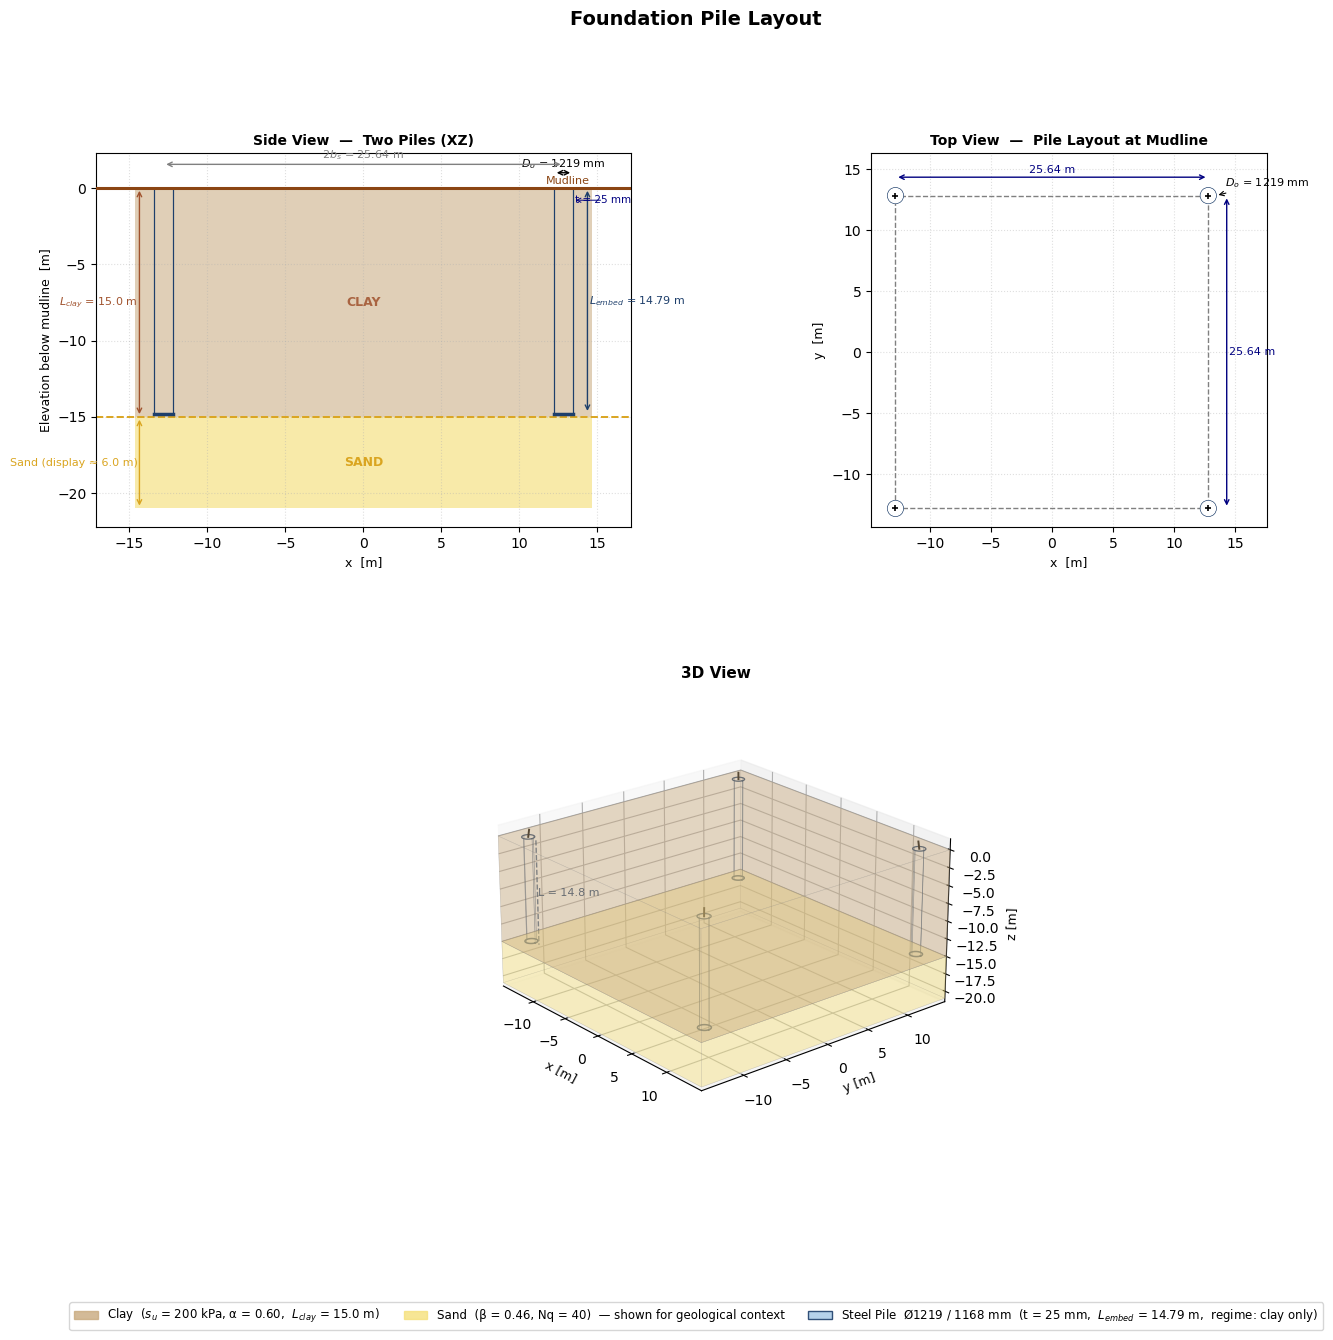

In [ ]:
# Visualization of pile layout and soil layers
R_o = D_o / 2.0
R_i = D_i / 2.0
z_tip = -L_embed

# Always show both soil layers; use actual sand depth or a proportional display depth
L_sand_disp = L_sand_solution if L_sand_solution > 0 else round(L_clay * 0.40, 1)
z_sand_bot  = -(L_clay + L_sand_disp)          # bottom of sand display band
z_buf       = z_sand_bot - 1.2                 # figure bottom margin
w_soil      = max(R_o * 7.0, 2.0)

# Pile positions = jacket leg bases at seabed (z ≈ 0)
_sb = sorted({(round(x, 2), round(y, 2))
              for _, (x, y, z) in nodes_3d.items() if abs(z) < 0.1})
if len(_sb) == 4:
    pile_xy = _sb
    b_s = max(abs(p[0]) for p in pile_xy)
else:
    b_s = L_jacket * np.tan(alpha)   # fallback from jacket geometry
    pile_xy = [( b_s,  b_s), ( b_s, -b_s), (-b_s,  b_s), (-b_s, -b_s)]

pile_fc = '#aecde8'
pile_ec = '#1e3f6b'

# ── Figure layout: side + top on top row, large 3D view below ─────────────────
fig = plt.figure(figsize=(16, 13))
fig.suptitle("Foundation Pile Layout", fontsize=14, fontweight='bold', y=0.99)

gs = gridspec.GridSpec(2, 2, figure=fig,
                       height_ratios=[1, 1.25],
                       hspace=0.38, wspace=0.32)
ax1 = fig.add_subplot(gs[0, 0])
ax2 = fig.add_subplot(gs[0, 1])
ax3 = fig.add_subplot(gs[1, :], projection='3d')

# ══════════════════════════════════════════════════════════════════════════════
# (A)  SIDE VIEW — two piles at ±b_s (XZ plane)
# ══════════════════════════════════════════════════════════════════════════════
ax1.set_title("Side View  —  Two Piles (XZ)", fontsize=10, fontweight='bold')
ax1.set_xlabel("x  [m]", fontsize=9)
ax1.set_ylabel("Elevation below mudline  [m]", fontsize=9)
ax1.grid(True, ls=':', alpha=0.4)

# Soil extent to cover both piles + margin
sv_margin  = R_o + 1.2
sv_x_left  = -(b_s + sv_margin)
sv_x_right =  (b_s + sv_margin)

# Soil fills — always show both layers
ax1.fill_betweenx([-L_clay, 0.0], sv_x_left, sv_x_right,
                  color='#c8a97d', linewidth=0, alpha=0.55, zorder=1)
ax1.fill_betweenx([z_sand_bot, -L_clay], sv_x_left, sv_x_right,
                  color='#f5e07b', linewidth=0, alpha=0.65, zorder=1)

# Clay / sand interface line
ax1.axhline(-L_clay, color='goldenrod', lw=1.4, ls='--', zorder=2)

# Draw both piles at x = -b_s and x = +b_s
for px_sv in [-b_s, b_s]:
    ax1.fill_betweenx([z_tip, 0.0], px_sv - R_o, px_sv - R_i, color=pile_fc, linewidth=0, zorder=3)
    ax1.fill_betweenx([z_tip, 0.0], px_sv + R_i, px_sv + R_o, color=pile_fc, linewidth=0, zorder=3)
    for xv in [px_sv - R_o, px_sv - R_i, px_sv + R_i, px_sv + R_o]:
        ax1.plot([xv, xv], [z_tip, 0.0], color=pile_ec, lw=0.8, zorder=4)
    ax1.plot([px_sv - R_o, px_sv + R_o], [0.0,   0.0  ], color=pile_ec, lw=2.0, zorder=5)
    ax1.plot([px_sv - R_o, px_sv + R_o], [z_tip, z_tip], color=pile_ec, lw=2.5, zorder=5)

# Mudline
ax1.axhline(0.0, color='saddlebrown', lw=2.2, zorder=6)
ax1.text(sv_x_right - 0.1, 0.25, 'Mudline', ha='right', fontsize=8, color='saddlebrown')

# Soil layer labels (centred between the two piles)
ax1.text(0, -L_clay / 2,
         'CLAY', ha='center', va='center', fontsize=9,
         color='sienna', fontweight='bold', alpha=0.85, zorder=7)
ax1.text(0, -(L_clay + L_sand_disp / 2),
         'SAND', ha='center', va='center', fontsize=9,
         color='goldenrod', fontweight='bold', zorder=7)

# ── Dimension lines ────────────────────────────────────────────────────────────
# D_o: horizontal, above mudline on the right pile
y_do = 1.0
ax1.annotate('', xy=(b_s + R_o, y_do), xytext=(b_s - R_o, y_do),
             arrowprops=dict(arrowstyle='<->', color='k', lw=1.0, mutation_scale=8))
ax1.text(b_s, y_do + 0.15, f'$D_o$ = {D_o*1e3:.0f} mm',
         ha='center', va='bottom', fontsize=8)

# Pile spacing: between the two pile centres
y_sp = 1.55
ax1.annotate('', xy=(b_s, y_sp), xytext=(-b_s, y_sp),
             arrowprops=dict(arrowstyle='<->', color='gray', lw=1.0, mutation_scale=8))
ax1.text(0, y_sp + 0.15, f'$2b_s$ = {2*b_s:.2f} m',
         ha='center', va='bottom', fontsize=8, color='gray')

# L_embed: right outer side
x_dr = b_s + sv_margin * 0.85
ax1.annotate('', xy=(x_dr, z_tip), xytext=(x_dr, 0.0),
             arrowprops=dict(arrowstyle='<->', color=pile_ec, lw=1.0, mutation_scale=8))
ax1.text(x_dr + 0.10, z_tip / 2,
         f'$L_{{embed}}$ = {L_embed:.2f} m',
         ha='left', va='center', fontsize=8, color=pile_ec)

# L_clay: left outer side
x_dl = -(b_s + sv_margin * 0.85)
ax1.annotate('', xy=(x_dl, -L_clay), xytext=(x_dl, 0.0),
             arrowprops=dict(arrowstyle='<->', color='sienna', lw=1.0, mutation_scale=8))
ax1.text(x_dl - 0.10, -L_clay / 2,
         f'$L_{{clay}}$ = {L_clay:.1f} m',
         ha='right', va='center', fontsize=8, color='sienna')

# L_sand: left outer side, below clay bracket
ax1.annotate('', xy=(x_dl, z_sand_bot), xytext=(x_dl, -L_clay),
             arrowprops=dict(arrowstyle='<->', color='goldenrod', lw=1.0, mutation_scale=8))
lbl_sand = (f'$L_{{sand}}$ = {L_sand_solution:.1f} m'
            if L_sand_solution > 0 else f'Sand (display ≈ {L_sand_disp:.1f} m)')
ax1.text(x_dl - 0.10, -(L_clay + L_sand_disp / 2),
         lbl_sand, ha='right', va='center', fontsize=8, color='goldenrod')

# Wall thickness on outer wall of right pile
ax1.annotate(f't = {(R_o - R_i)*1e3:.0f} mm',
             xy=(b_s + R_o, -0.8), xytext=(b_s + R_o + 0.15, -0.8),
             arrowprops=dict(arrowstyle='->', color='navy', lw=0.7),
             fontsize=7.5, color='navy', va='center')

ax1.set_xlim(sv_x_left - 2.5, sv_x_right + 2.5)
ax1.set_ylim(z_buf, 2.3)

# ══════════════════════════════════════════════════════════════════════════════
# (B)  TOP VIEW — pile layout at mudline
# ══════════════════════════════════════════════════════════════════════════════
ax2.set_title("Top View  —  Pile Layout at Mudline", fontsize=10, fontweight='bold')
ax2.set_xlabel("x  [m]", fontsize=9)
ax2.set_ylabel("y  [m]", fontsize=9)
ax2.set_aspect('equal')
ax2.grid(True, ls=':', alpha=0.4)

for (px, py) in pile_xy:
    ax2.add_patch(plt.Circle((px, py), R_o, color=pile_fc, ec=pile_ec, lw=1.5, zorder=3))
    ax2.add_patch(plt.Circle((px, py), R_i, color='white', zorder=4))
    ax2.plot(px, py, 'k+', ms=5, mew=1.2, zorder=5)

xs_p = [p[0] for p in pile_xy];  ys_p = [p[1] for p in pile_xy]
xmin_p, xmax_p = min(xs_p), max(xs_p)
ymin_p, ymax_p = min(ys_p), max(ys_p)

ax2.add_patch(mpatches.Rectangle(
    (xmin_p, ymin_p), xmax_p - xmin_p, ymax_p - ymin_p,
    fill=False, ec='gray', ls='--', lw=1.0, zorder=2))

marg = R_o + 0.9
ax2.annotate('', xy=(xmax_p, ymax_p + marg), xytext=(xmin_p, ymax_p + marg),
             arrowprops=dict(arrowstyle='<->', color='navy', lw=1.0, mutation_scale=8))
ax2.text((xmin_p + xmax_p) / 2, ymax_p + marg + 0.15,
         f'{xmax_p - xmin_p:.2f} m', ha='center', va='bottom', fontsize=8, color='navy')

ax2.annotate('', xy=(xmax_p + marg, ymax_p), xytext=(xmax_p + marg, ymin_p),
             arrowprops=dict(arrowstyle='<->', color='navy', lw=1.0, mutation_scale=8))
ax2.text(xmax_p + marg + 0.15, (ymin_p + ymax_p) / 2,
         f'{ymax_p - ymin_p:.2f} m', ha='left', va='center', fontsize=8, color='navy')

ax2.annotate(f'$D_o$ = {D_o*1e3:.0f} mm',
             xy=(xmax_p + R_o, ymax_p),
             xytext=(xmax_p + R_o + 0.8, ymax_p + 0.8),
             arrowprops=dict(arrowstyle='->', color='k', lw=0.8), fontsize=8)

ax2.set_xlim(xmin_p - 2.0, xmax_p + 4.8)
ax2.set_ylim(ymin_p - 1.5, ymax_p + 3.5)

# ══════════════════════════════════════════════════════════════════════════════
# (C)  3D VIEW — full-width bottom panel
# ══════════════════════════════════════════════════════════════════════════════
ax3.set_title("3D View", fontsize=11, fontweight='bold')
ax3.set_xlabel("x [m]", fontsize=9)
ax3.set_ylabel("y [m]", fontsize=9)
ax3.set_zlabel("z [m]", fontsize=9)

sl = b_s + 2.0

def _soil_box(ax, xl, yl, z_b, z_t, color, alpha=0.25):
    faces = [
        [[-xl,-yl,z_t],[ xl,-yl,z_t],[ xl, yl,z_t],[-xl, yl,z_t]],
        [[-xl,-yl,z_b],[ xl,-yl,z_b],[ xl, yl,z_b],[-xl, yl,z_b]],
        [[-xl,-yl,z_b],[-xl,-yl,z_t],[-xl, yl,z_t],[-xl, yl,z_b]],
        [[ xl,-yl,z_b],[ xl,-yl,z_t],[ xl, yl,z_t],[ xl, yl,z_b]],
        [[-xl,-yl,z_b],[ xl,-yl,z_b],[ xl,-yl,z_t],[-xl,-yl,z_t]],
        [[-xl, yl,z_b],[ xl, yl,z_b],[ xl, yl,z_t],[-xl, yl,z_t]],
    ]
    ax.add_collection3d(Poly3DCollection(
        faces, alpha=alpha, facecolor=color, edgecolor='gray', linewidth=0.3))

# Always show both soil layers
_soil_box(ax3, sl, sl, -L_clay, 0.0, '#c8a97d')
_soil_box(ax3, sl, sl, z_sand_bot, -L_clay, '#f5e07b')

# Piles — rings + vertical generators
theta_c = np.linspace(0, 2 * np.pi, 36)
for (px, py) in pile_xy:
    xc = px + R_o * np.cos(theta_c)
    yc = py + R_o * np.sin(theta_c)
    ax3.plot(xc, yc, [0.0]      * 36, color=pile_ec, lw=0.9)
    ax3.plot(xc, yc, [z_tip]    * 36, color=pile_ec, lw=1.1)
    for ki in range(0, 36, 9):
        ax3.plot([xc[ki], xc[ki]], [yc[ki], yc[ki]], [0.0, z_tip],
                 color=pile_ec, lw=0.45, alpha=0.65)

# Jacket legs above mudline: seabed → first horizontal ring
z_r1 = horiz_levels[0]
for (px, py) in pile_xy:
    _dist = np.hypot(px, py)
    _sc   = 1.0 - np.tan(alpha) * z_r1 / _dist
    ax3.plot([px, px * _sc], [py, py * _sc], [0.0, z_r1], 'k-', lw=1.4)

# L_embed annotation on one pile
p0x, p0y = pile_xy[0]
ax3.plot([p0x + R_o + 0.6] * 2, [p0y] * 2, [0.0, z_tip],
         color=pile_ec, lw=1.0, ls='--', alpha=0.8)
ax3.text(p0x + R_o + 0.7, p0y, z_tip / 2,
         f'L = {L_embed:.1f} m', fontsize=8, color=pile_ec, va='center')

ax3.set_xlim(-sl, sl)
ax3.set_ylim(-sl, sl)
ax3.set_zlim(z_sand_bot - 0.5, 1.5)
ax3.view_init(elev=22, azim=-40)
ax3.set_box_aspect([1, 1, 0.55])

# ── Shared legend ──────────────────────────────────────────────────────────────
p_clay = mpatches.Patch(color='#c8a97d', alpha=0.8,
                        label=f'Clay  ($s_u$ = {s_u/1e3:.0f} kPa, '
                              f'α = {alpha_sf:.2f},  $L_{{clay}}$ = {L_clay:.1f} m)')
lbl_sand_leg = (f'Sand  (β = {beta:.2f}, Nq = {Nq},  '
                f'$L_{{sand}}$ = {L_sand_solution:.2f} m)'
                if L_sand_solution > 0 else
                f'Sand  (β = {beta:.2f}, Nq = {Nq})  — shown for geological context')
p_sand = mpatches.Patch(color='#f5e07b', alpha=0.8, label=lbl_sand_leg)
p_pile = mpatches.Patch(color=pile_fc, ec=pile_ec, alpha=0.9,
                        label=(f'Steel Pile  Ø{D_o*1e3:.0f} / {D_i*1e3:.0f} mm  '
                               f'(t = {t*1e3:.0f} mm,  $L_{{embed}}$ = {L_embed:.2f} m,  '
                               f'regime: {regime})'))

fig.legend(handles=[p_clay, p_sand, p_pile],
           loc='lower center', ncol=3,
           fontsize=8.5, bbox_to_anchor=(0.5, -0.03), frameon=True)

plt.tight_layout(rect=[0, 0.04, 1, 0.98])
plt.show()


## Frame Analysis

In [ ]:

## Lumped joint loads from distributed hydrodynamic loading


# Select governing hydro case
gov_case = next(cr for cr in case_results if '53.7' in cr['label'])

z_abs_gov   = np.array(gov_case['z_abs'])    # elevation above seabed [m]
forces_gov  = np.array(gov_case['forces'])   # f_H(z)  [N/m]
z_crest_gov = gov_case['h'] + gov_case['zeta_cr']

# Bay boundaries: seabed → ring levels → wave crest
bay_bounds = sorted(set([0.0] + list(horiz_levels) + [z_crest_gov]))

# Integrate f_H over each bay
bay_forces   = []   # F_H,i  [N]
bay_z_centro = []   # true centroid elevation of each bay's load [m]

for z_lo, z_hi in zip(bay_bounds[:-1], bay_bounds[1:]):
    mask = (z_abs_gov >= z_lo) & (z_abs_gov <= z_hi)
    z_seg = z_abs_gov[mask]; f_seg = forces_gov[mask]
    if len(z_seg) == 0 or z_seg[0] > z_lo:
        z_seg = np.insert(z_seg, 0, z_lo)
        f_seg = np.insert(f_seg, 0, np.interp(z_lo, z_abs_gov, forces_gov))
    if z_seg[-1] < z_hi:
        z_seg = np.append(z_seg, z_hi)
        f_seg = np.append(f_seg, np.interp(z_hi, z_abs_gov, forces_gov))
    F_Hi = np.trapezoid(f_seg, z_seg)
    bay_forces.append(F_Hi)
    # centroid z of this bay's load (moment / force, both about seabed)
    centroid = np.trapezoid(f_seg * z_seg, z_seg) / F_Hi if F_Hi != 0 else (z_lo+z_hi)/2
    bay_z_centro.append(centroid)

bay_forces   = np.array(bay_forces)
bay_z_centro = np.array(bay_z_centro)

# Distribute to joints
n_joints_per_level = 4
joint_loads = {z: 0.0 for z in bay_bounds}
for i, (z_lo, z_hi) in enumerate(zip(bay_bounds[:-1], bay_bounds[1:])):
    contrib = bay_forces[i] / (2 * n_joints_per_level)   # [N] per joint
    joint_loads[z_lo] += contrib
    joint_loads[z_hi] += contrib

# Verification: base shear & overturning moment
# Base shear — identical for both distributed and lumped formulations
F_B_dist   = np.trapezoid(forces_gov, z_abs_gov)             # ∫f_H dz  [N]
F_B_lumped = sum(joint_loads.values()) * n_joints_per_level  # Σ F_H,i  [N]

# Overturning moment about seabed (z = 0) ─ distributed
M_OE_dist   = np.trapezoid(forces_gov * z_abs_gov, z_abs_gov)   # ∫f_H·z dz  [N·m]

# Overturning moment about seabed ─ lumped
# Each bay contributes F_H,i/2 at z_lo and F_H,i/2 at z_hi  → mid-bay z
M_OE_lumped = sum(
    bay_forces[i] / 2 * (bay_bounds[i] + bay_bounds[i+1])
    for i in range(len(bay_forces))
) # [N·m]

delta_M = M_OE_lumped - M_OE_dist   # positive = lumped overestimates


# Print results table
print(f"LUMPED JOINT LOADS — Governing hydro case: {gov_case['label']}")
print(f"  (f_H integrated per bay, distributed to {n_joints_per_level} joints/level)")
print()
print(f"{'Joint z [m]':>13}  {'Bay below [kN]':>16}  {'Bay above [kN]':>16}  {'F_joint [kN]':>14}  {'F_level [kN]':>14}")
print("-" * 80)
for idx, z in enumerate(bay_bounds):
    F_below = bay_forces[idx-1] / 1e3 if idx > 0              else 0.0
    F_above = bay_forces[idx]   / 1e3 if idx < len(bay_forces) else 0.0
    F_jnt   = joint_loads[z] / 1e3
    F_lvl   = joint_loads[z] * n_joints_per_level / 1e3
    print(f"{z:>13.2f}  {F_below:>16.2f}  {F_above:>16.2f}  {F_jnt:>14.3f}  {F_lvl:>14.3f}")
print("-" * 80)
print()
print("VERIFICATION — base shear preserved, overturning moment changes:")
print(f"  {'':30s}  {'Distributed':>14}  {'Lumped':>14}  {'Δ':>10}")
print(f"  {'Base shear F_B  [kN]':30s}  {F_B_dist/1e3:>14.2f}  {F_B_lumped/1e3:>14.2f}  {(F_B_lumped-F_B_dist)/1e3:>10.2f}")
print(f"  {'OTM about seabed [MN·m]':30s}  {M_OE_dist/1e6:>14.3f}  {M_OE_lumped/1e6:>14.3f}  {delta_M/1e6:>10.3f}")
print()



LUMPED JOINT LOADS — Governing hydro case: D_max = 53.7 m
  (f_H integrated per bay, distributed to 4 joints/level)

  Joint z [m]    Bay below [kN]    Bay above [kN]    F_joint [kN]    F_level [kN]
--------------------------------------------------------------------------------
         0.00              0.00             44.64           5.580          22.321
         1.00             44.64            186.13          28.846         115.385
        26.31            186.13            185.67          46.474         185.898
        46.53            185.67             91.42          34.636         138.543
        58.51             91.42              0.00          11.427          45.709
--------------------------------------------------------------------------------

VERIFICATION — base shear preserved, overturning moment changes:
                                     Distributed          Lumped           Δ
  Base shear F_B  [kN]                    509.34          507.85       -1.48
  OTM abo

In [ ]:
## Lumped wind loads — applied at first H-ring above SWL (tower base joint)

z_top_frame = max(horiz_levels)         # highest hydro ring [m above seabed]

# z_wind_lump: first H-ring strictly above the governing-case SWL
# SWL (still water level) = water depth for the governing wave case
z_swl = gov_case['h']   # still water level above seabed [m]
_h_ring_zs_above_swl = sorted({
    round(nodes_3d[e['nodes'][0]][2], 3)
    for e in elements
    if e.get('type') == 'H'
    and abs(nodes_3d[e['nodes'][0]][2] - nodes_3d[e['nodes'][1]][2]) < 0.01
    and nodes_3d[e['nodes'][0]][2] > z_swl
})
z_wind_lump = _h_ring_zs_above_swl[0]   # lowest H-ring above SWL

# b_1: half the span between windward and leeward node groups at the wind lumping level
# Wind acts in +x direction (0° heading), so the relevant span is the x-extent
top_nodes_x = [x for (x, y, z) in nodes_3d.values()
               if abs(z - z_wind_lump) < 0.1]
b_1 = (max(top_nodes_x) - min(top_nodes_x)) / 2   # [m]

# Effective arm a — moment of all wind forces about the wind lumping elevation
M_wind_lump = M_wind_total - F_wind_total * z_wind_lump   # residual moment [N·m]
a_wind = M_wind_lump / F_wind_total                        # arm above z_wind_lump [m]

# Lumped loads per joint
F_w_hor  = F_wind_total / 4                     # horizontal [N] — same at all 4 joints
F_w_vert = F_wind_total * a_wind / (4 * b_1)    # vertical [N] per joint
print("LUMPED WIND LOADS — first H-ring above SWL (tower base joint)")
# Print summary
print(f"  Governing case SWL (h)          = {z_swl:.3f} m  above seabed")
print(f"  Wind lumping elevation      z  = {z_wind_lump:.3f} m  (1st H-ring above SWL)")
print(f"  Half windward-leeward span b_1 = {b_1:.2f} m")
print()
print(f"  Total wind force           F_w   = {F_wind_total/1e3:.2f} kN")
print(f"  Moment about seabed              = {M_wind_total/1e6:.3f} MN·m")
print(f"  Moment about wind joint          = {M_wind_lump/1e6:.3f} MN·m")
print(f"  Effective arm above wind joint a = {a_wind:.2f} m")
print()
print(f" Per joint — horizontal : F_w·hor  = F_w / 4")
print(f"   {F_w_hor/1e3:>10.3f} kN  (→ all 4 joints)")
print(f" Per joint — vertical   : F_w·vert = F_w·a / (4·b_1) ")
print(f"   {F_w_vert/1e3:>10.3f} kN  (magnitude)")
print()
# Verification
M_check = 4 * F_w_vert * b_1
print(f"  CHECK — restoring moment: 4 × F_w,vert × b_1 = {M_check/1e6:.3f} MN·m")
print(f"          applied moment:   F_w × a             = {F_wind_total*a_wind/1e6:.3f} MN·m")


print(f"          applied moment:   F_w × a             = {F_wind_total*a_wind/1e6:.3f} MN·m")

LUMPED WIND LOADS — first H-ring above SWL (tower base joint)
  Governing case SWL (h)          = 53.700 m  above seabed
  Wind lumping elevation      z  = 62.667 m  (1st H-ring above SWL)
  Half windward-leeward span b_1 = 6.44 m

  Total wind force           F_w   = 1021.71 kN
  Moment about seabed              = 145.508 MN·m
  Moment about wind joint          = 81.481 MN·m
  Effective arm above wind joint a = 79.75 m

 Per joint — horizontal : F_w·hor  = F_w / 4
      255.427 kN  (→ all 4 joints)
 Per joint — vertical   : F_w·vert = F_w·a / (4·b_1) 
     3161.041 kN  (magnitude)

  CHECK — restoring moment: 4 × F_w,vert × b_1 = 81.481 MN·m
          applied moment:   F_w × a             = 81.481 MN·m
          applied moment:   F_w × a             = 81.481 MN·m


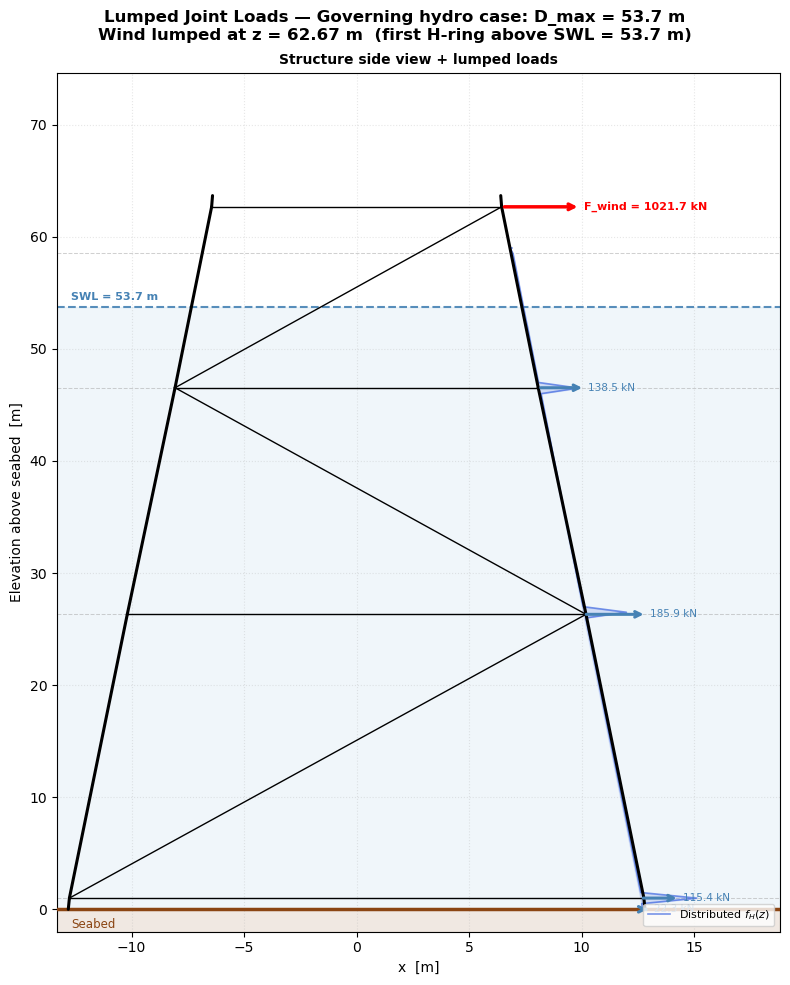

In [ ]:
## Plot — Lumped joint loads on jacket side view

fig_lump, ax_lj = plt.subplots(1, 1, figsize=(8, 10))
fig_lump.suptitle(
    f"Lumped Joint Loads — Governing hydro case: {gov_case['label']}\n"
    f"Wind lumped at z = {z_wind_lump:.2f} m  (first H-ring above SWL = {z_swl:.1f} m)",
    fontsize=12, fontweight='bold')

y_lo = -2.0
y_hi = z_wind_lump + max(3.0, a_wind * 0.15)

ax_lj.set_ylim(y_lo, y_hi)
# Seabed
ax_lj.axhline(0, color='saddlebrown', lw=2.5, zorder=3)
ax_lj.axhspan(y_lo, 0, alpha=0.12, color='saddlebrown', zorder=1)
# Water column
ax_lj.axhspan(0, z_swl, alpha=0.10, color='#74add1', zorder=1)
ax_lj.axhline(z_swl, color='steelblue', lw=1.5, ls='--', alpha=0.9)
ax_lj.text(0.02, z_swl + 0.5, f'SWL = {z_swl:.1f} m', transform=ax_lj.get_yaxis_transform(),
        fontsize=8, color='steelblue', fontweight='bold', va='bottom')
# Ring dashed lines at bay boundaries
for z_b in bay_bounds:
    ax_lj.axhline(z_b, color='#aaa', ls='--', lw=0.75, alpha=0.55)
ax_lj.grid(True, ls=':', alpha=0.3)

# ── Structure side view + distributed curve + lumped arrows ───────────────────
ax_lj.set_title("Structure side view + lumped loads", fontsize=10, fontweight='bold')
ax_lj.set_xlabel("x  [m]")
ax_lj.set_ylabel("Elevation above seabed  [m]")

# Draw face members (y > 0)
_face = [m for m in members if nodes[m['start']][1] > 0 and nodes[m['end']][1] > 0]
for m in _face:
    xi_, yi_, zi_ = nodes[m['start']]
    xj_, yj_, zj_ = nodes[m['end']]
    lw_ = 2.2 if m.get('type') == 'Leg' else 1.0
    ax_lj.plot([xi_, xj_], [zi_, zj_], 'k-', lw=lw_, solid_capstyle='round', zorder=4)

# Distributed hydro curve (right side, thin) — reference background
f_scale = 2.5 / max(forces_gov) if max(forces_gov) > 0 else 1.0
ax_lj.fill_betweenx(z_abs_gov,
                    [half_span_at(z) for z in z_abs_gov],
                    [half_span_at(z) + f * f_scale for z, f in zip(z_abs_gov, forces_gov)],
                    alpha=0.18, color='royalblue', zorder=2)
ax_lj.plot([half_span_at(z) + f * f_scale for z, f in zip(z_abs_gov, forces_gov)],
           z_abs_gov, color='royalblue', lw=1.2, alpha=0.7, label='Distributed $f_H(z)$')

# Lumped hydro arrows — only at levels at or below SWL
F_lvl_max = max(joint_loads[z] * n_joints_per_level for z in bay_bounds if joint_loads[z] > 0)
arr_scale = 2.8 / F_lvl_max if F_lvl_max > 0 else 1.0
for z_b in bay_bounds:
    if z_b > z_swl:          # skip levels above still-water line
        continue
    F_jnt = joint_loads[z_b]
    if F_jnt < 1.0:
        continue
    F_lvl_kN = F_jnt * n_joints_per_level / 1e3
    x0 = half_span_at(z_b)
    x1_ = x0 + F_jnt * n_joints_per_level * arr_scale
    ax_lj.annotate('', xy=(x1_, z_b), xytext=(x0, z_b),
                   arrowprops=dict(arrowstyle='->', color='steelblue', lw=2.2), zorder=5)
    ax_lj.text(x1_ + 0.15, z_b, f'{F_lvl_kN:.1f} kN',
               ha='left', va='center', fontsize=7.5, color='steelblue')

# Wind lumped horizontal arrow at z_wind_lump
F_wind_kN = F_wind_total / 1e3
x0_w = half_span_at(z_wind_lump)
wind_vis = max(1.5, min(F_wind_total * arr_scale, 3.5))
x1_w = x0_w + wind_vis
ax_lj.annotate('', xy=(x1_w, z_wind_lump), xytext=(x0_w, z_wind_lump),
               arrowprops=dict(arrowstyle='->', color='red', lw=2.5), zorder=6)
ax_lj.text(x1_w + 0.15, z_wind_lump, f'F_wind = {F_wind_kN:.1f} kN',
           ha='left', va='center', fontsize=8, color='red', fontweight='bold')

# Seabed label
ax_lj.text(0.02, -0.8, 'Seabed', transform=ax_lj.get_yaxis_transform(),
           color='saddlebrown', fontsize=8.5, va='top')

_x_vals = [nodes[id_][0] for m in _face for id_ in (m['start'], m['end'])]
ax_lj.set_xlim(min(_x_vals) - 0.5, max(_x_vals) + 6.0)
ax_lj.legend(fontsize=8, loc='lower right')

plt.tight_layout()
plt.show()


In [ ]:
## FRAME ANALYSIS — Environmental Loading (Lecture 12, slide 66)

# Geometry at each ring level
z_bot_frame = min(horiz_levels)

# Frame levels: 3 hydro rings + z_wind_lump (tower base joint above MSL)
frame_levels_top2bot = sorted(set(horiz_levels) | {z_wind_lump}, reverse=True)

# b_s: half windward-leeward span at seabed (legs incline outward going down)
# b_1 is measured at z_wind_lump; legs taper at angle alpha going downward
b_s = b_1 + z_wind_lump * np.tan(alpha)

# half-span as function of elevation (linear taper between b_1 at z_wind_lump and b_s at seabed)
def half_span_at(z):
    return b_1 + (z_wind_lump - z) * np.tan(alpha)

# Collect total horizontal force at each structural ring level
# joint_loads[z] = hydro force per joint [N] (bay-boundary nodes redistributed below)
F_level = {}
for z in horiz_levels:
    F_level[z] = 4.0 * joint_loads.get(z, 0.0) # hydro × 4 joints
F_level[z_wind_lump] = 0.0 # initialise wind-lump level

# Seabed (z=0) load to add to bottom hydro ring
z_seabed_key = min(bay_bounds)
if z_seabed_key not in horiz_levels:
    F_level[z_bot_frame] += 4.0 * joint_loads.get(z_seabed_key, 0.0)

# Wave-crest node load to add to top hydro ring (no structural joint above z_top_frame below MSL)
z_crest_key = max(bay_bounds)
if z_crest_key not in horiz_levels:
    F_level[z_top_frame] += 4.0 * joint_loads.get(z_crest_key, 0.0)

# Add total wind horizontal force at the tower base joint (first H-ring above MSL)
F_level[z_wind_lump] += F_wind_total

# STEP 3: Base Shear and OTM from lumped loads
F_B_frame = sum(F_level.values())
# OTM: each force acts at its ring elevation; wind is at z_wind_lump but
# effectively acts at (z_wind_lump + a_wind), so correct for the extra arm
M_OE_frame = sum(F * z for z, F in F_level.items()) + F_wind_total * a_wind
# (the F_wind_total × z_wind_lump was already included via F_level; add a_wind arm)
M_OE_frame += M_vertical_total # moment from gravity eccentricities

# STEP 4: Support reactions from rotation pole method
R_a = Pa_design # axial pile reaction per pile  [N]
R_t = Pt_design # transverse pile reaction per pile [N]
R_m = Pm_design # pile moment per pile [N·m]

# STEP 5: Shear at all joint elevations — free-body (cantilever) approach
# Working top to bottom: V(z) = sum of all lumped horizontal loads at rings ≥ z
# Starts at zero above z_wind_lump, grows to F_B_frame at the bottom ring.

V_at = {}
V_cur = 0.0
for z in frame_levels_top2bot: # top to bottom
    V_cur += F_level[z]
    V_at[z] = V_cur

V_mudline_check = F_B_frame # total base shear = sum of all lumped loads

# STEP 6: Moment at all joint elevations — free-body approach
# M_1  = F_w·a (moment of wind forces above z_wind_lump, about z_wind_lump)
# M_{k+1} = M_k + V_k · h_k (shear × bay height; V is the slope of M)
# Mudline check: propagated M_mudline should equal M_OE_frame

M_at = {}
for i, z in enumerate(frame_levels_top2bot):
    if i == 0:
        M_at[z] = F_wind_total * a_wind # wind OTM above z_wind_lump
    else:
        z_above = frame_levels_top2bot[i - 1]
        h_bay   = z_above - z # height of bay above this ring
        M_at[z] = M_at[z_above] + V_at[z_above] * h_bay

# Propagate to mudline (leg segment below bottom ring)
M_mudline = M_at[z_bot_frame] + V_at[z_bot_frame] * z_bot_frame
M_mudline_check = M_OE_frame - M_vertical_total

# PRINT
print("=" * 70)
print("FRAME ANALYSIS — Steps 3–6")
print("=" * 70)
print()
print("STEP 3 — Base Shear & OTM (lumped loads about seabed)")
print(f" Base shear F_B = {F_B_frame/1e3:>10.2f} kN")
print(f" OTM at seabed = {M_OE_frame/1e6:>10.3f} MN·m")
print()
print("STEP 4 — Support reactions (from rotation pole method)")
print(f" R_a = Pa = {R_a/1e3:>8.2f} kN /pile (axial)")
print(f" R_t = Pt = {R_t/1e3:>8.2f} kN /pile (transverse)")
print(f" R_m = Pm = {R_m/1e3:>8.2f} kN·m/pile (moment)")
print(f" α = {np.degrees(alpha):.3f}°")
print(f" b_1 = {b_1:.2f} m (at z_wind_lump = {z_wind_lump:.3f} m),  b_s = {b_s:.2f} m (seabed half-span)")
print()
print("STEPS 5 & 6 — Shear-line and Moment-line")
print(f" {'Ring z [m]':>10}  {'F level [kN]':>14}  {'Shear V [kN]':>14}  {'Moment M [MN·m]':>17}")
print("  " + "-" * 60)
for z in frame_levels_top2bot:
    print(f"  {z:>10.2f}  {F_level[z]/1e3:>14.2f}  {V_at[z]/1e3:>14.2f}  {M_at[z]/1e6:>17.4f}")
print("  " + "-" * 60)
print(f"{'Mudline':>10}  {'':14}  {V_mudline_check/1e3:>14.2f}  {M_mudline/1e6:>17.4f}")
print()
print("CHECKS at mudline:")
print(f" V_bottom (V-line) = {V_at[z_bot_frame]/1e3:>10.2f} kN")
print(f" F_B_frame (Σloads) = {V_mudline_check/1e3:>10.2f} kN  (Δ = {(V_at[z_bot_frame]-V_mudline_check)/1e3:+.2f} kN)")
print(f" M_mudline (M-line) = {M_mudline/1e6:>10.4f} MN·m")
print(f" M_horiz (ΣF·z+F_w·a) = {M_mudline_check/1e6:>10.4f} MN·m  (Δ = {(M_mudline-M_mudline_check)/1e6:+.4f} MN·m)")


FRAME ANALYSIS — Steps 3–6

STEP 3 — Base Shear & OTM (lumped loads about seabed)
 Base shear F_B =    1529.56 kN
 OTM at seabed =    301.710 MN·m

STEP 4 — Support reactions (from rotation pole method)
 R_a = Pa = 13222.25 kN /pile (axial)
 R_t = Pt =   -37.50 kN /pile (transverse)
 R_m = Pm =  -137.86 kN·m/pile (moment)
 α = 5.711°
 b_1 = 6.44 m (at z_wind_lump = 62.667 m),  b_s = 12.71 m (seabed half-span)

STEPS 5 & 6 — Shear-line and Moment-line
 Ring z [m]    F level [kN]    Shear V [kN]    Moment M [MN·m]
  ------------------------------------------------------------
       62.67         1021.71         1021.71            81.4808
       46.53          184.25         1205.96            97.9711
       26.31          185.90         1391.86           122.3472
        1.00          137.71         1529.56           157.5806
  ------------------------------------------------------------
   Mudline                         1529.56           159.1101

CHECKS at mudline:
 V_bottom (V-line)

In [ ]:
handles, labels = ax_l.get_legend_handles_labels()
ax_l.legend(handles=handles, labels=labels, fontsize=8.5,
            loc='upper left', bbox_to_anchor=(0.0, -0.10),
            ncol=2, framealpha=0.92)
ax_l.get_figure().tight_layout()
plt.show()


C:\Users\rutge\AppData\Local\Temp\ipykernel_5708\3794313673.py:2: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax_l.legend(handles=handles, labels=labels, fontsize=8.5,


NameError: name 'gov_case' is not defined

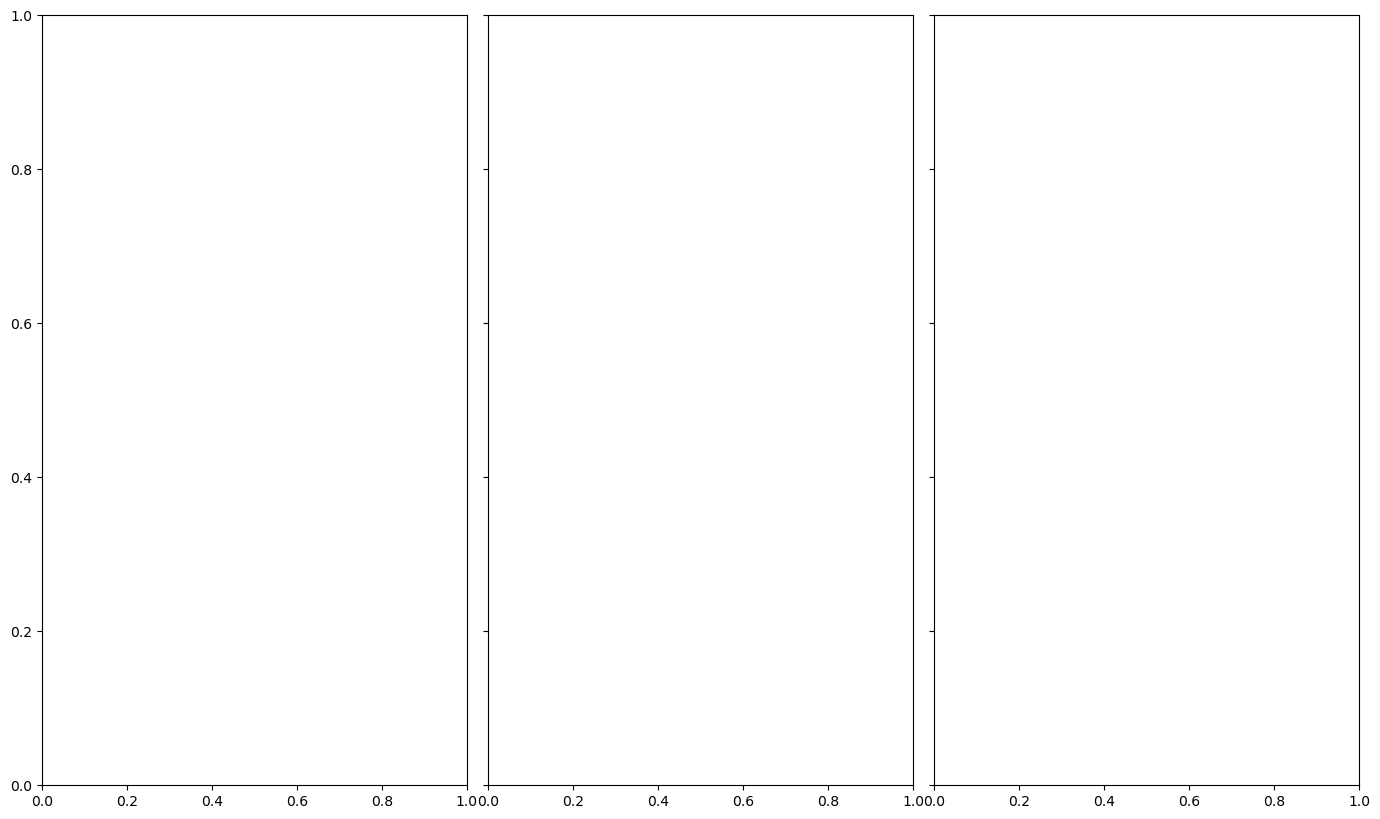

In [ ]:
## Plot the Shear and Moment lines

fig, (ax_S, ax_V, ax_M) = plt.subplots(
    1, 3, figsize=(17, 10), sharey=True,
    gridspec_kw={'width_ratios': [1, 1, 1], 'wspace': 0.05})
fig.suptitle(
    f"Frame Analysis — Beam model, Shear-line & Moment-line\n"
    f"Governing case: {gov_case['label']}  |  α = {np.degrees(alpha):.2f}°",
    fontsize=12, fontweight='bold')

y_min = -3.0
y_max = frame_levels_top2bot[0] + 6.0 # top of highest frame level (z_wind_lump)

# Common decorations (seabed, soil fill, MSL, water column, ring dashed lines) on all panels
for ax in (ax_S, ax_V, ax_M):
    ax.set_ylim(y_min, y_max)
    # Seabed
    ax.axhline(0, color='saddlebrown', linewidth=2.5, zorder=3)
    ax.axhspan(y_min, 0, alpha=0.12, color='saddlebrown', zorder=2)
    # Water column (seabed → MSL)
    ax.axhspan(0, z_MSL_abs, alpha=0.10, color='#74add1', zorder=1)
    # MSL line
    ax.axhline(z_MSL_abs, color='steelblue', linewidth=1.6, linestyle='--', alpha=0.9, zorder=4)
    # Ring dashed lines
    for z_ring in frame_levels_top2bot:
        ax.axhline(z_ring, color='#888', linestyle='--', linewidth=0.9, alpha=0.65, zorder=1)

# MSL label on shear and moment panels only (structure panel gets its own)
for ax in (ax_V, ax_M):
    ax.text(0.02, z_MSL_abs + 0.8, 'MSL', transform=ax.get_yaxis_transform(),
            fontsize=8, color='steelblue', fontweight='bold', va='bottom')

# PANEL 1: Actual 2-D structure side view (y > 0 face)
ax_S.set_title("2-D frame — face view  (y > 0)", fontsize=11, fontweight='bold')
ax_S.set_xlabel("x  [m]")
ax_S.set_ylabel("Elevation above seabed  [m]")
ax_S.axvline(0, color='silver', linewidth=0.5, linestyle=':')
ax_S.text(0.02, z_MSL_abs + 0.8, 'MSL', transform=ax_S.get_yaxis_transform(),
          fontsize=8, color='steelblue', fontweight='bold', va='bottom')

# Draw actual member geometry from the y>0 face (same as structure side-view plot)
_face_mems = [m for m in members if nodes[m['start']][1] > 0 and nodes[m['end']][1] > 0]
for m in _face_mems:
    xi, yi, zi = nodes[m['start']]
    xj, yj, zj = nodes[m['end']]
    lw = 2.5 if m.get('type') == 'Leg' else 1.2
    ax_S.plot([xi, xj], [zi, zj], 'k-', linewidth=lw, solid_capstyle='round', zorder=4)

# x limits from actual node positions + room for load arrows on the right
_x_vals = [nodes[id_][0] for m in _face_mems for id_ in (m['start'], m['end'])]
ax_S.set_xlim(min(_x_vals) - 1.5, max(_x_vals) + 5.5)

# Ring elevation labels on the left
for z_ring in frame_levels_top2bot:
    ax_S.text(-half_span_at(z_ring) - 0.3, z_ring,
              f'{z_ring:.1f} m', ha='right', va='center', fontsize=7.5, color='#444')

# Lumped load arrows on the right (starting from right-leg edge at each ring)
F_max_lvl = max(abs(F_level.get(z, 0)) for z in frame_levels_top2bot) or 1.0
arr_max = 0.65 * b_1
for z_ring in frame_levels_top2bot:
    Fz = F_level.get(z_ring, 0.0)
    if abs(Fz) < 1.0:
        continue
    x_start = half_span_at(z_ring)
    arr = arr_max * abs(Fz) / F_max_lvl
    ax_S.annotate('', xy=(x_start + arr, z_ring), xytext=(x_start, z_ring),
                  arrowprops=dict(arrowstyle='->', color='steelblue', lw=2.0), zorder=5)
    ax_S.text(x_start + arr + 0.2, z_ring, f'{Fz/1e3:.1f} kN',
              ha='left', va='center', fontsize=7, color='steelblue')

# Support reaction arrows below seabed
for sign in (-1, 1):
    ax_S.annotate('', xy=(sign * b_s, -2.0), xytext=(sign * b_s, 0),
                  arrowprops=dict(arrowstyle='->', color='tomato', lw=1.8), zorder=5)
ax_S.text(0, -1.5, f'Rₜ={R_t/1e3:.1f} kN   Rₐ={R_a/1e3:.1f} kN',
          ha='center', va='center', fontsize=7.5, color='tomato',
          bbox=dict(boxstyle='round,pad=0.2', fc='white', alpha=0.85, ec='tomato'))

# PANEL 2: V-line (step function, max at bottom)
ax_V.set_title("Shear-line", fontsize=11, fontweight='bold')
ax_V.set_xlabel("Shear  V  [kN]")
ax_V.axvline(0, color='k', linewidth=1.2)

# Build staircase: V=0 down from y_max to top ring level; step at each ring going down
V_pz = [y_max, frame_levels_top2bot[0]] # zero shear above top frame level
V_pv = [0.0,   0.0]
V_cur = 0.0
for z_ring in frame_levels_top2bot: # top → bottom
    V_next = V_at[z_ring]
    V_pz += [z_ring, z_ring] # horizontal step at ring level
    V_pv += [V_cur,  V_next] # jump to new V value
    V_cur = V_next
    # connect down to next ring (or to seabed)
    z_next = frame_levels_top2bot[frame_levels_top2bot.index(z_ring) + 1] \
             if z_ring != frame_levels_top2bot[-1] else 0.0
    V_pz.append(z_next)
    V_pv.append(V_cur)

V_pv_arr = np.array(V_pv) / 1e3
ax_V.plot(V_pv_arr, V_pz, color='steelblue', linewidth=2.8, zorder=4)
ax_V.fill_betweenx(V_pz, 0, V_pv_arr, alpha=0.18, color='steelblue', zorder=3)

# Value label at each step (positioned just after the jump)
for z_ring in frame_levels_top2bot:
    ax_V.text(V_at[z_ring] / 1e3, z_ring + 0.5,
              f'V={V_at[z_ring]/1e3:.1f} kN',
              ha='center', va='bottom', fontsize=7.5, color='navy',
              bbox=dict(boxstyle='round,pad=0.10', fc='white', alpha=0.85, ec='none'))

# Mudline check label
ax_V.text(V_at[min(horiz_levels)] / 1e3, 0.7,
          f'F_B = {V_mudline_check/1e3:.1f} kN',
          ha='center', va='bottom', fontsize=7.5, color='saddlebrown',
          bbox=dict(boxstyle='round,pad=0.15', fc='wheat', alpha=0.9, ec='saddlebrown'))
ax_V.grid(True, linestyle=':', alpha=0.35)

# PANEL 3: M-line (piecewise linear, angle changes at kinks) 
ax_M.set_title("Moment-line", fontsize=11, fontweight='bold')
ax_M.set_xlabel("Moment  M  [MN·m]")
ax_M.axvline(0, color='k', linewidth=1.2)

# Piecewise linear: ring elevations → mudline (z=0). Stops at seabed.
M_pz = list(frame_levels_top2bot) + [0.0, 0.0]
M_pv = np.array([M_at[z] for z in frame_levels_top2bot] + [M_mudline, 0.0]) / 1e6
# Line starts exactly at the top frame level (z_wind_lump), no extension above
# Last two points close the diagram with a bold vertical drop to M=0 at the seabed
M_pz_full = M_pz
M_pv_full = M_pv

ax_M.plot(M_pv_full, M_pz_full, color='tomato', linewidth=2.8, zorder=4)
ax_M.fill_betweenx(M_pz_full, 0, M_pv_full, alpha=0.18, color='tomato', zorder=3)

# M value labels at each ring
for z_ring in frame_levels_top2bot:
    ax_M.text(M_at[z_ring] / 1e6, z_ring + 0.5,
              f'M={M_at[z_ring]/1e6:.2f}',
              ha='center', va='bottom', fontsize=7.5, color='darkred',
              bbox=dict(boxstyle='round,pad=0.10', fc='white', alpha=0.85, ec='none'))

# Mudline check label
ax_M.text(M_mudline / 1e6, 0.7,
          f'M_mud={M_mudline/1e6:.2f} MN·m\nM_OE={M_mudline_check/1e6:.2f} MN·m',
          ha='center', va='bottom', fontsize=7, color='saddlebrown',
          bbox=dict(boxstyle='round,pad=0.15', fc='wheat', alpha=0.9, ec='saddlebrown'))

# Angle-change markers at each intermediate ring
plt.tight_layout()
fig.canvas.draw() 

inv = ax_M.transData.inverted()

for k in range(1, len(frame_levels_top2bot)):
    z_k = frame_levels_top2bot[k]
    z_above = frame_levels_top2bot[k - 1]
    z_below = frame_levels_top2bot[k + 1] if k + 1 < len(frame_levels_top2bot) else 0.0
    M_k = M_at[z_k]   / 1e6
    M_above = M_at[z_above] / 1e6
    M_below = (M_at[z_below] if z_below in M_at else M_mudline) / 1e6

    # Convert to display (pixel) coordinates
    pk = np.array(ax_M.transData.transform([M_k,     z_k]))
    pa = np.array(ax_M.transData.transform([M_above, z_above]))
    pb = np.array(ax_M.transData.transform([M_below, z_below]))

    # Unit direction vectors in display space
    da = pa - pk; da /= (np.linalg.norm(da) or 1)
    db = pb - pk; db /= (np.linalg.norm(db) or 1)

    # Two points 18 px from the kink, one on each segment
    R_px = 18
    pta = inv.transform(pk + R_px * da) # data coords
    ptb = inv.transform(pk + R_px * db)

    # Arc (concave bracket) connecting the two tangent arms
    patch = FancyArrowPatch(
        posA=tuple(pta), posB=tuple(ptb),
        connectionstyle='arc3,rad=-0.45',
        arrowstyle='-', color='darkred', lw=1.8, zorder=7)
    ax_M.add_patch(patch)

    # Kink angle in display space → label interior of arc
    cos_a = float(np.clip(np.dot(da, db), -1.0, 1.0))
    kink_deg = np.degrees(np.arccos(cos_a))
    bisect_disp = pk + 30 * (da + db) / max(np.linalg.norm(da + db), 1e-9)
    lbl_pt = inv.transform(bisect_disp)
    ax_M.text(lbl_pt[0], lbl_pt[1], f'{kink_deg:.0f}°',
              ha='center', va='center', fontsize=8, color='darkred', fontweight='bold',
              bbox=dict(boxstyle='round,pad=0.12', fc='mistyrose', alpha=0.9, ec='none'),
              zorder=8)

# Large dot at each kink
for z_ring in frame_levels_top2bot[1:]:
    ax_M.plot(M_at[z_ring] / 1e6, z_ring, 'o', color='darkred', ms=7, zorder=6)

# V-slope labels on each M-line segment
all_M_pts = list(frame_levels_top2bot) + [0.0]
all_M_vals = [M_at[z] / 1e6 for z in frame_levels_top2bot] + [M_mudline / 1e6]
for k in range(len(all_M_pts) - 1):
    z_top_seg = all_M_pts[k];   z_bot_seg = all_M_pts[k + 1]
    z_mid = (z_top_seg + z_bot_seg) / 2
    M_mid = (all_M_vals[k] + all_M_vals[k + 1]) / 2
    V_seg = V_at[all_M_pts[k]]   # shear = slope dM/dz in this bay
    ax_M.text(M_mid - 0.05, z_mid,
              f'slope = V = {V_seg/1e3:.1f} kN',
              ha='right', va='center', fontsize=7, color='firebrick', style='italic')

ax_M.grid(True, linestyle=':', alpha=0.35)
plt.show()


In [ ]:
# Simple cross-section method (lecture 12 style) for all members
print("\n" + "="*60)
print("AXIAL FORCES IN ALL MEMBERS (Simple cross-section, z-bracing)")
print("="*60)

import math

# Leg axial from moment line (same as textbook stage)
N_leg = {}
for z in frame_levels_top2bot:
    b = half_span_at(z)
    if abs(b) < 1e-9:
        continue
    N_leg[z] = M_at[z] / (2.0 * b)

# mudline leg axial (from mudline moment)
b_mud = half_span_at(0.0)
N_leg_mud = M_mudline / (2.0 * b_mud)

N_member = {}

# count number of K bracing in each level for load distribution
levels_K = {}
for m in members:
    if norm_type(m['type']) in ('K', 'D'):
        z_mid = (nodes_3d[m['start']][2] + nodes_3d[m['end']][2]) / 2.0
        z_key = round(z_mid, 2)
        levels_K[z_key] = levels_K.get(z_key, 0) + 1

for m in members:
    typ = norm_type(m['type'])
    n1, n2 = m['start'], m['end']
    z1 = nodes_3d[n1][2]
    z2 = nodes_3d[n2][2]
    z_upper = max(z1, z2)
    z_mid = (z1 + z2)/2.0

    if typ == 'Leg':
        if abs(z_upper) < 1e-6:
            N_member[m['id']] = N_leg_mud
        else:
            N_member[m['id']] = N_leg.get(z_upper, 0.0)

    elif typ in ('K', 'D'):
        dz = abs(z2 - z1)
        dx = math.hypot(nodes_3d[n2][0] - nodes_3d[n1][0], nodes_3d[n2][1] - nodes_3d[n1][1])
        theta = math.atan2(dx, dz) if dz > 0 else math.pi/2
        sin_theta = math.sin(theta) if abs(math.sin(theta)) > 1e-9 else 1e-9

        # Use shear at nearest ring, fallback to 0
        z_near = min(frame_levels_top2bot, key=lambda z: abs(z - z_mid))
        Vz = V_at.get(z_near, 0.0)

        nK = levels_K.get(round(z_mid, 2), 1)
        # per-brace axial from shear equilibrium (2 braces share each side in simplified model)
        N_member[m['id']] = Vz / max(1, nK) / sin_theta

    elif typ == 'H':
        # horizontal members: axial from redistributed shear (if any)
        z_near = min(frame_levels_top2bot, key=lambda z: abs(z - z_mid))
        Vz = V_at.get(z_near, 0.0)
        # approximated as part of horizontal shear carry
        N_member[m['id']] = Vz / 4.0

    else:
        N_member[m['id']] = 0.0

# Print results
print(f"{'Member ID':>10}  {'Type':>8}  {'N [kN]':>12}")
print("-" * 35)
for m in members:
    print(f"{m['id']:>10}  {norm_type(m['type']):>8}  {N_member[m['id']]/1e3:>12.2f}")


AXIAL FORCES IN ALL MEMBERS (Simple cross-section, z-bracing)


NameError: name 'frame_levels_top2bot' is not defined

In [ ]:
"""
D. MEMBER DESIGN VERIFICATION
Verification of structural members following EN 1993-1-1:2021 and DNVGL-ST-0126:2018
Including: Cross-section verification, Axial load verification, and Bending verification
"""

import numpy as np
import pandas as pd
from scipy import stats
import matplotlib.pyplot as plt

print("="*80)
print("D. MEMBER DESIGN VERIFICATION")
print("="*80)

# ============================================================================
# D.1 - MATERIAL AND DESIGN PARAMETERS
# ============================================================================
print("\n--- D.1: MATERIAL AND DESIGN PARAMETERS ---")

# Steel properties
fy_steel = 355  # MPa - yield strength (S355)
E_steel = 210000  # MPa - Young's modulus
nu = 0.3  # Poisson's ratio

# Partial safety factors (Offshore: DNVGL-ST-0126:2018)
gamma_M0 = 1.1  # Partial factor for cross-section resistance
gamma_M1 = 1.1  # Partial factor for instability
gamma_M5 = 1.25  # Partial factor for ultimate limit state

# Load factors
load_factor = 1.0  # User should set appropriate load factors from analysis

# Marine growth parameters
rho_sw = 1025  # kg/m³ - seawater density
g = 9.81  # m/s² - gravity
t_mg = 0.05  # m - marine growth thickness

print(f"Yield strength fy = {fy_steel} MPa")
print(f"Young's modulus E = {E_steel} MPa")
print(f"Partial safety factors: γM0 = {gamma_M0}, γM1 = {gamma_M1}")

# ============================================================================
# D.2 - CREATE MEMBER VERIFICATION DATAFRAME
# ============================================================================
print("\n--- D.2: MEMBER VERIFICATION ANALYSIS ---")

# Initialize verification results dataframe
verification_results = []

# Get member data from existing dataframes
for idx, member_row in elem_df.iterrows():
    elem_id = member_row['Element_ID']
    node1 = member_row['Node_1']
    node2 = member_row['Node_2']
    D_member = member_row['D']  # Diameter in meters
    t_member = member_row['t']  # Wall thickness in meters
    L_member = member_row['Length']  # Length in meters
    
    # Get axial force from N_member dictionary (from previous cell)
    N_Ed_kN = N_member.get(elem_id, 0.0) / 1000  # Convert from N to kN
    N_Ed_N = N_Ed_kN * 1000  # Back to N for calcs
    
    # ========================================================================
    # D.2.1 - CROSS-SECTION VERIFICATION
    # ========================================================================
    
    # Cross-sectional area (gross section)
    A = np.pi * (D_member**2 - (D_member - 2*t_member)**2) / 4
    
    # Second moment of inertia
    D_i = D_member - 2*t_member  # Inner diameter
    I = np.pi * (D_member**4 - D_i**4) / 64
    
    # Radius of gyration
    r = np.sqrt(I / A) if A > 0 else 0
    
    # Axial stress
    sigma_Ed = abs(N_Ed_N) / (A * 1e6) if A > 0 else 0  # MPa
    
    # Design plastic resistance
    N_pl_Rd = A * fy_steel / gamma_M0  # N
    
    # Design compression resistance (for Class 1, 2, 3)
    N_c_Rd = N_pl_Rd  # N
    sigma_Rd = fy_steel / gamma_M0  # MPa
    
    # Cross-section utilization ratio
    utilization_cs = sigma_Ed / sigma_Rd if sigma_Rd > 0 else 0
    cs_ok = utilization_cs <= 1.0
    
    # ========================================================================
    # D.2.2 - MEMBER VERIFICATION (FLEXURAL BUCKLING)
    # ========================================================================
    
    # Effective buckling length (assume pinned-pinned conditions)
    Le = L_member
    
    # Slenderness
    lambda_val = Le / r if r > 0 else 0
    
    # Relative slenderness threshold
    fy_ref = 235  # MPa - Reference yield strength
    lambda_1 = np.pi * np.sqrt(E_steel / fy_steel)  # Adjusted for actual fy
    
    # Relative slenderness
    beta_A = 1.0  # For Class 1, 2, 3
    lambda_rel = (lambda_val / lambda_1) * np.sqrt(beta_A)
    
    # Select buckling curve (for welded hollow sections in bending: curve 'c')
    alpha_imperfection = 0.49  # For curve c
    
    # Reduction factor χ for buckling
    phi = 0.5 * (1 + alpha_imperfection * (lambda_rel - 0.2) + lambda_rel**2)
    chi = 1.0 / (phi + np.sqrt(phi**2 - lambda_rel**2)) if (phi**2 - lambda_rel**2) >= 0 else 0.1
    chi = min(chi, 1.0)
    
    # Design buckling resistance
    N_b_Rd = chi * beta_A * A * fy_steel / gamma_M1  # N
    
    # Member utilization ratio (axial) - use absolute value for compression/tension
    utilization_ax = abs(N_Ed_N) / N_b_Rd if N_b_Rd > 0 else float('inf')
    ax_ok = utilization_ax <= 1.0
    
    # ========================================================================
    # D.2.3 - LATERAL LOADS AND BENDING VERIFICATION
    # ========================================================================
    
    # Lateral loads components (placeholder - should be from hydrodynamic analysis)
    q1 = 0.0  # N/m - Hydrodynamic load (Morison)
    q2 = A * 7850 * g / 1000  # N/m - Self-weight (assuming steel density 7850 kg/m³)
    
    # Buoyancy (dry case)
    D_with_mg = D_member + 2 * t_mg
    q3a = np.pi * D_with_mg * t_mg * rho_sw * g / 1000  # N/m
    q3b = rho_sw * g * np.pi / 4 * (D_with_mg**2 - D_member**2) / 1000  # N/m (flooded)
    
    # Maximum lateral load
    q_max = abs(q1 + q2 - q3a)  # Dry case (conservative)
    q_max_fl = abs(q1 + q2 - q3b)  # Flooded case
    q_design = max(q_max, q_max_fl)
    
    # Bending moment
    M_Ed = q_design * L_member**2 / 12 if q_design > 0 else 0  # N⋅m
    
    # Section modulus (elastic and plastic)
    W_el = np.pi * (D_member**4 - D_i**4) / (32 * D_member) if D_member > 0 else 0  # m³
    W_pl = W_el * 1.27 if W_el > 0 else 0  # Approximate for circular sections
    
    # Bending moment resistance (Class 1 and 2)
    M_Rd = W_pl * fy_steel / gamma_M0 if W_pl > 0 else 0  # N⋅m
    
    # Bending utilization ratio
    utilization_bending = M_Ed / M_Rd if M_Rd > 0 else 0
    bending_ok = utilization_bending <= 1.0
    
    # ========================================================================
    # D.2.4 - COMBINED STRESS CHECK (INTERACTION)
    # ========================================================================
    
    # Simplified interaction formula (EN 1993-1-1)
    # For members in compression and bending
    N_y_Rd = chi * A * fy_steel / gamma_M1  # N
    
    # Interaction parameter (simplified)
    k_interaction = 0.95  # Approximation for RHS in bending
    
    # Interaction check
    interaction_ratio = utilization_ax + k_interaction * utilization_bending
    interaction_ok = interaction_ratio <= 1.0
    
    # ========================================================================
    # D.2.5 - D/t RATIO CHECK (BALANCED DESIGN)
    # ========================================================================
    
    d_over_t = D_member / t_member if t_member > 0 else 0
    d_over_t_ok = 25 <= d_over_t <= 50
    
    # Store results
    result = {
        'Element_ID': elem_id,
        'Node_1': node1,
        'Node_2': node2,
        'D (m)': D_member,
        't (m)': t_member,
        'D/t': d_over_t,
        'Length (m)': L_member,
        'Area (mm²)': A * 1e6,
        'N_Ed (kN)': N_Ed_kN,
        'Compression_OK': cs_ok,
        'CS_Util (-)': utilization_cs,
        'Lambda_rel (-)': lambda_rel,
        'Buckling_OK': ax_ok,
        'Axial_Util (-)': utilization_ax,
        'M_Ed (kN⋅m)': M_Ed / 1e6,
        'Bending_OK': bending_ok,
        'Bending_Util (-)': utilization_bending,
        'Interaction_OK': interaction_ok,
        'Interaction_Ratio (-)': interaction_ratio,
        'D/t_OK': d_over_t_ok,
        'Overall_OK': cs_ok and ax_ok and bending_ok and interaction_ok and d_over_t_ok
    }
    
    verification_results.append(result)

# Create results dataframe
verification_df = pd.DataFrame(verification_results)

# ============================================================================
# D.3 - RESULTS SUMMARY
# ============================================================================
print("\n" + "="*80)
print("MEMBER DESIGN VERIFICATION RESULTS SUMMARY")
print("="*80)

# Display key results
print("\nDetailed Member Verification:")
print(verification_df.to_string(index=False))

# Summary statistics
print("\n" + "="*80)
print("VERIFICATION STATUS SUMMARY")
print("="*80)

n_members = len(verification_df)
n_cs_ok = verification_df['Compression_OK'].sum()
n_ax_ok = verification_df['Buckling_OK'].sum()
n_bend_ok = verification_df['Bending_OK'].sum()
n_int_ok = verification_df['Interaction_OK'].sum()
n_dt_ok = verification_df['D/t_OK'].sum()
n_overall_ok = verification_df['Overall_OK'].sum()

print(f"\nTotal members analyzed: {n_members}")
print(f"Cross-section verification OK: {n_cs_ok}/{n_members} ({100*n_cs_ok/n_members:.1f}%)")
print(f"Buckling verification OK: {n_ax_ok}/{n_members} ({100*n_ax_ok/n_members:.1f}%)")
print(f"Bending verification OK: {n_bend_ok}/{n_members} ({100*n_bend_ok/n_members:.1f}%)")
print(f"Interaction check OK: {n_int_ok}/{n_members} ({100*n_int_ok/n_members:.1f}%)")
print(f"D/t ratio OK: {n_dt_ok}/{n_members} ({100*n_dt_ok/n_members:.1f}%)")
print(f"OVERALL VERIFICATION OK: {n_overall_ok}/{n_members} ({100*n_overall_ok/n_members:.1f}%)")

# ============================================================================
# D.4 - CRITICAL MEMBERS IDENTIFICATION
# ============================================================================
print("\n" + "="*80)
print("CRITICAL MEMBERS (not satisfying criteria)")
print("="*80)

critical_members = verification_df[~verification_df['Overall_OK']]
if len(critical_members) > 0:
    print(f"\nFound {len(critical_members)} critical members:")
    print(critical_members[['Element_ID', 'D/t', 'CS_Util', 'Axial_Util', 
                            'Bending_Util', 'Interaction_Ratio', 'Overall_OK']].to_string(index=False))
else:
    print("\nAll members satisfy design criteria!")

# ============================================================================
# D.5 - VISUALIZATION
# ============================================================================
fig, axes = plt.subplots(2, 3, figsize=(15, 10))
fig.suptitle('Member Design Verification Results', fontsize=14, fontweight='bold')

# Plot 1: Utilization ratios
ax = axes[0, 0]
x_pos = np.arange(len(verification_df))
ax.bar(x_pos - 0.2, verification_df['CS_Util'], 0.2, label='Cross-section', alpha=0.8)
ax.bar(x_pos, verification_df['Axial_Util'], 0.2, label='Axial (Buckling)', alpha=0.8)
ax.bar(x_pos + 0.2, verification_df['Bending_Util'], 0.2, label='Bending', alpha=0.8)
ax.axhline(y=1.0, color='r', linestyle='--', linewidth=2, label='Limit')
ax.set_xlabel('Element ID')
ax.set_ylabel('Utilization Ratio (-)')
ax.set_title('Utilization Ratios by Member')
ax.legend(fontsize=8)
ax.grid(axis='y', alpha=0.3)

# Plot 2: Interaction ratio
ax = axes[0, 1]
colors = ['green' if x else 'red' for x in verification_df['Interaction_OK']]
ax.bar(verification_df['Element_ID'], verification_df['Interaction_Ratio'], color=colors, alpha=0.7)
ax.axhline(y=1.0, color='r', linestyle='--', linewidth=2, label='Limit')
ax.set_xlabel('Element ID')
ax.set_ylabel('Interaction Ratio (-)')
ax.set_title('Combined Stress Interaction Check')
ax.legend()
ax.grid(axis='y', alpha=0.3)

# Plot 3: D/t ratio
ax = axes[0, 2]
colors = ['green' if x else 'red' for x in verification_df['D/t_OK']]
ax.bar(verification_df['Element_ID'], verification_df['D/t'], color=colors, alpha=0.7)
ax.axhline(y=25, color='orange', linestyle='--', linewidth=1.5, label='Min limit (25)')
ax.axhline(y=50, color='orange', linestyle='--', linewidth=1.5, label='Max limit (50)')
ax.fill_between([-1, len(verification_df)], 25, 50, alpha=0.1, color='green')
ax.set_xlabel('Element ID')
ax.set_ylabel('D/t Ratio (-)')
ax.set_title('Diameter-to-Thickness Ratio')
ax.legend(fontsize=8)
ax.grid(axis='y', alpha=0.3)

# Plot 4: Slenderness ratio
ax = axes[1, 0]
ax.bar(verification_df['Element_ID'], verification_df['Lambda_rel'], color='steelblue', alpha=0.7)
ax.set_xlabel('Element ID')
ax.set_ylabel('Relative Slenderness (-)')
ax.set_title('Member Slenderness')
ax.grid(axis='y', alpha=0.3)

# Plot 5: Verification status
ax = axes[1, 1]
verification_status = pd.DataFrame({
    'Cross-section': [n_cs_ok, n_members - n_cs_ok],
    'Buckling': [n_ax_ok, n_members - n_ax_ok],
    'Bending': [n_bend_ok, n_members - n_bend_ok],
    'Interaction': [n_int_ok, n_members - n_int_ok]
}, index=['OK', 'NOT OK'])

verification_status.plot(kind='bar', ax=ax, color=['green', 'red'], alpha=0.7)
ax.set_ylabel('Number of Members')
ax.set_title('Verification Status Summary')
ax.set_xticklabels(ax.get_xticklabels(), rotation=0)
ax.legend(fontsize=8)
ax.grid(axis='y', alpha=0.3)

# Plot 6: Design factors utilization
ax = axes[1, 2]
avg_cs = verification_df['CS_Util'].mean()
avg_ax = verification_df['Axial_Util'].mean()
avg_bend = verification_df['Bending_Util'].mean()
avg_int = verification_df['Interaction_Ratio'].mean()

categories = ['Cross-section', 'Axial', 'Bending', 'Interaction']
values = [avg_cs, avg_ax, avg_bend, avg_int]
colors_avg = ['green' if x <= 1 else 'red' for x in values]

ax.barh(categories, values, color=colors_avg, alpha=0.7)
ax.axvline(x=1.0, color='r', linestyle='--', linewidth=2, label='Limit')
ax.set_xlabel('Average Utilization Ratio (-)')
ax.set_title('Average Utilization by Check Type')
ax.legend()
ax.grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.show()

print("\n" + "="*80)
print("Member design verification complete.")
print("="*80)

D. MEMBER DESIGN VERIFICATION

--- D.1: MATERIAL AND DESIGN PARAMETERS ---
Yield strength fy = 355 MPa
Young's modulus E = 210000 MPa
Partial safety factors: γM0 = 1.1, γM1 = 1.1

--- D.2: MEMBER VERIFICATION ANALYSIS ---


KeyError: 'Element_ID'